# MS Control Prediction — Multi-Model ML with Bayesian Optimization & SHAP

| Item | Detail |
|---|---|
| **Dataset** | New_Processed_MS_Control.csv (n = 472) |
| **Target** | `MS_Control` — Binary: 0 = Not Controlled, 1 = Controlled |
| **Models** | ANN (Keras), MLP, Random Forest, CatBoost, XGBoost, LightGBM, AdaBoost |
| **Tuning** | Bayesian Optimisation (`scikit-optimize`) |
| **XAI** | SHAP — Beeswarm, Bar, Waterfall, Force, Dependence, Heatmap |

---
## ⚠️ Why Train/Test (80/20) + Cross-Validation — NOT a 3-way split

With only **472 samples**, a 3-way split gives ~330 train / ~71 val / ~71 test samples — each set is too small for stable metric estimates.

**Correct approach for small datasets:**
- **80 % Train / 20 % Test** — hold-out test set is untouched until final evaluation
- **Stratified 5-fold Cross-Validation** on the training set for Bayesian hyperparameter tuning
- Final performance is reported **only on the held-out test set**

---
## Notebook Sections
1. Setup & Imports
2. Data Loading & EDA
3. Train / Test Split (80/20) + Scaling
4. Shared Evaluation Utility
5. ANN (Keras)
6. MLP (sklearn)
7. Random Forest
8. CatBoost
9. XGBoost
10. LightGBM
11. AdaBoost
12. Consolidated Comparison & Plots
13. SHAP Explainability (All Models)

## Section 1 — Setup & Imports

In [1]:
# Install required packages — comment out after first run
!pip install -q scikit-optimize catboost xgboost lightgbm shap tensorflow

In [2]:
# ==============================================================
# Standard libraries
# ==============================================================
import numpy as np
import pandas as pd
import warnings, os
warnings.filterwarnings('ignore')

# ==============================================================
# Visualisation
# ==============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================
# scikit-learn
# ==============================================================
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
    average_precision_score, auc,
    brier_score_loss
)
from sklearn.calibration import CalibrationDisplay

# ==============================================================
# Gradient boosting
# ==============================================================
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

# ==============================================================
# Bayesian Optimisation
# ==============================================================
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# ==============================================================
# Deep learning
# ==============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==============================================================
# SHAP
# ==============================================================
import shap

# ==============================================================
# Reproducibility
# ==============================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_style('white')
sns.set_context('paper', font_scale=1.4)
plt.rcParams.update({'figure.dpi': 120})

print('All libraries loaded.')

2026-05-07 07:52:16.798331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778140337.031196      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778140337.100413      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778140337.671417      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778140337.671460      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778140337.671464      57 computation_placer.cc:177] computation placer alr

All libraries loaded.


In [3]:
plt.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['DejaVu Serif'],  # always available
    'font.size'       : 12,
    'font.weight'     : 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 12,
    'legend.fontsize' : 12,
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12
})

## Section 2 — Data Loading & EDA

In [4]:
# --------------------------------------------------------------
# Load dataset — update DATA_PATH if needed
# --------------------------------------------------------------
DATA_PATH = '/kaggle/input/datasets/mdsoumikehassan/ms-control-dataset-2/New_Processed_MS_Control.csv'
data = pd.read_csv(DATA_PATH)

# Strip whitespace from column names
data.columns = data.columns.str.strip()

print(f'Shape  : {data.shape}')
print(f'Columns: {data.columns.tolist()}')
print(f"\nTarget distribution:\n{data['MS_Control'].value_counts()}")
data.head()

Shape  : (472, 26)
Columns: ['HosLevel', 'Sex', 'Religion', 'Marital Status', 'Education', 'Occupation', 'Age', 'Socio Economic Status', 'Family Types', 'Area of living', 'BMI', 'PolyPharmacy', 'MS_Control', 'Comorbidity', 'Dietary Patterns', 'Physical Activity', 'Medication Adharance', 'Community Participation', 'Clinic Service', 'Policy', 'Screening', 'Patterns of Health Education', 'Health behavior monitoring', 'Communities Outreach', 'NCD Drug Availability', 'Follow Up Patient']

Target distribution:
MS_Control
1    241
0    231
Name: count, dtype: int64


,HosLevel,Sex,Religion,Marital Status,Education,Occupation,Age,Socio Economic Status,Family Types,Area of living,...,Medication Adharance,Community Participation,Clinic Service,Policy,Screening,Patterns of Health Education,Health behavior monitoring,Communities Outreach,NCD Drug Availability,Follow Up Patient
0,1,2,3,2,2,5,1,1,1,1,...,0,0,1,0,0,0,1,1,1,1
1,3,2,2,2,4,6,3,1,1,2,...,2,0,2,1,1,0,1,0,1,1
2,3,2,2,2,5,1,1,2,1,2,...,1,0,2,1,1,0,1,0,1,1
3,3,2,3,2,3,1,3,3,1,1,...,1,2,2,1,1,2,0,0,1,1
4,2,1,3,2,1,4,2,2,1,1,...,1,0,1,1,1,2,0,0,2,1


In [5]:
data.columns

Index(['HosLevel', 'Sex', 'Religion', 'Marital Status', 'Education',
       'Occupation', 'Age', 'Socio Economic Status', 'Family Types',
       'Area of living', 'BMI', 'PolyPharmacy', 'MS_Control', 'Comorbidity',
       'Dietary Patterns', 'Physical Activity', 'Medication Adharance',
       'Community Participation', 'Clinic Service', 'Policy', 'Screening',
       'Patterns of Health Education', 'Health behavior monitoring',
       'Communities Outreach', 'NCD Drug Availability', 'Follow Up Patient'],
      dtype='object')

In [6]:
X = data.drop('MS_Control', axis=1)
y = data['MS_Control'].values

print(X)
print(y)

     HosLevel  Sex  Religion  Marital Status  Education  Occupation  Age  \
0           1    2         3               2          2           5    1   
1           3    2         2               2          4           6    3   
2           3    2         2               2          5           1    1   
3           3    2         3               2          3           1    3   
4           2    1         3               2          1           4    2   
..        ...  ...       ...             ...        ...         ...  ...   
467         3    1         3               2          1           4    2   
468         2    1         3               4          1           4    3   
469         2    2         3               2          5           4    3   
470         2    1         3               2          3           5    3   
471         2    1         3               2          5           4    2   

     Socio Economic Status  Family Types  Area of living  ...  \
0                     

Boruta Feature Selection — Correct Pipeline

--- Step 1: Train/Test Split (before Boruta) ---
Train set : (377, 25) — Boruta will fit on this only
Test set  : (95, 25) — untouched until evaluation

--- Step 2: Boruta fit on Train set only ---
Iteration: 1 / 100
Iteration: 2 / 100
Iteration: 3 / 100
Iteration: 4 / 100
Iteration: 5 / 100
Iteration: 6 / 100
Iteration: 7 / 100
Iteration: 8 / 100
Iteration: 9 / 100
Iteration: 10 / 100
Iteration: 11 / 100
Iteration: 12 / 100
Iteration: 13 / 100
Iteration: 14 / 100
Iteration: 15 / 100
Iteration: 16 / 100
Iteration: 17 / 100
Iteration: 18 / 100
Iteration: 19 / 100
Iteration: 20 / 100
Iteration: 21 / 100
Iteration: 22 / 100
Iteration: 23 / 100
Iteration: 24 / 100
Iteration: 25 / 100
Iteration: 26 / 100
Iteration: 27 / 100
Iteration: 28 / 100
Iteration: 29 / 100
Iteration: 30 / 100
Iteration: 31 / 100
Iteration: 32 / 100
Iteration: 33 / 100
Iteration: 34 / 100
Iteration: 35 / 100
Iteration: 36 / 100
Iteration: 37 / 100
Iteration: 38 / 100
Iterat

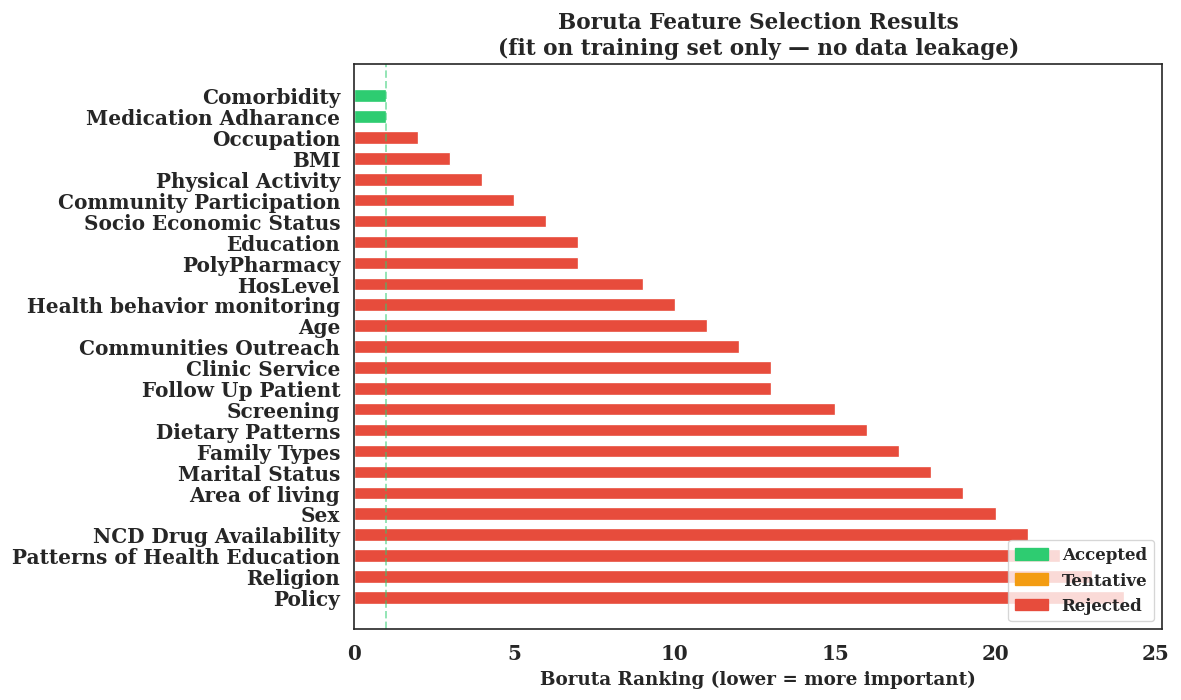

Saved: boruta_feature_status.png

--- Visualization 2: Feature Importance ---


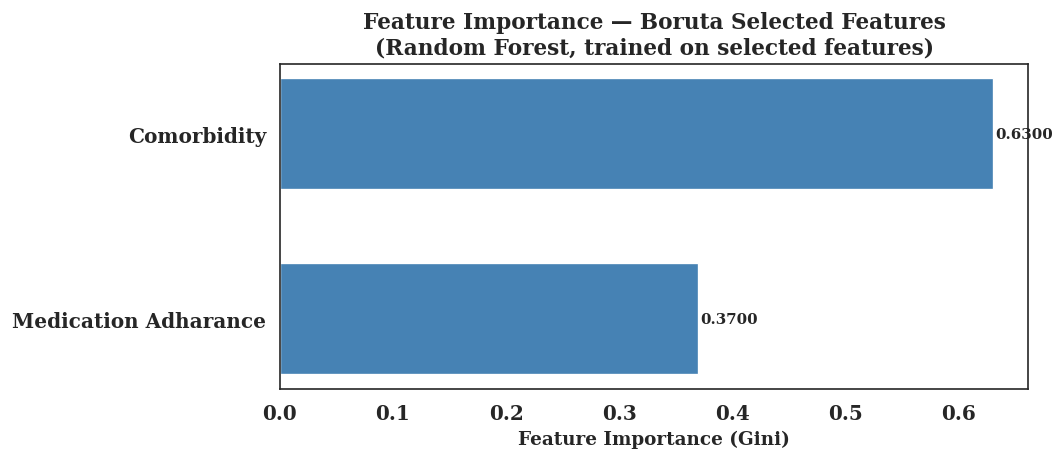

Saved: boruta_feature_importance.png

--- Visualization 3: Selection Summary Pie ---


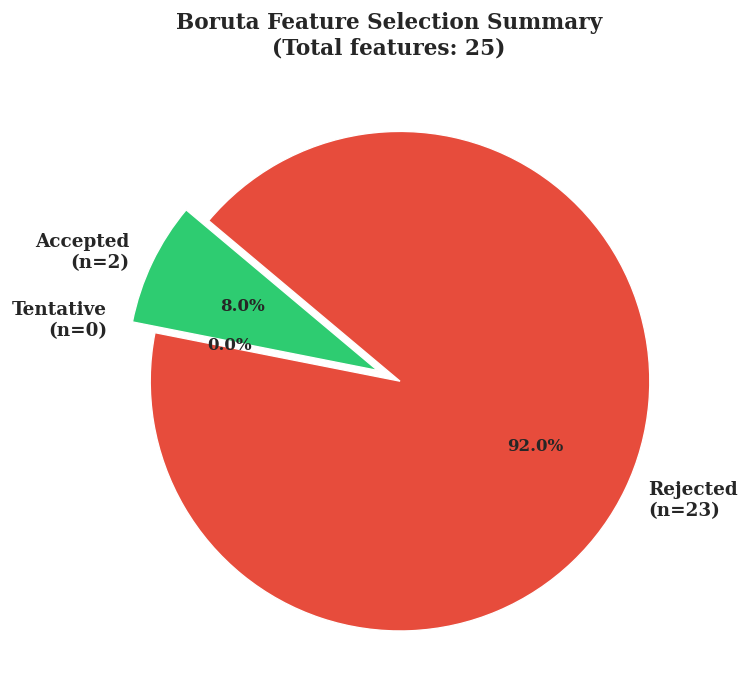

Saved: boruta_summary_pie.png

--- Visualization 4: Selected Feature Correlation ---


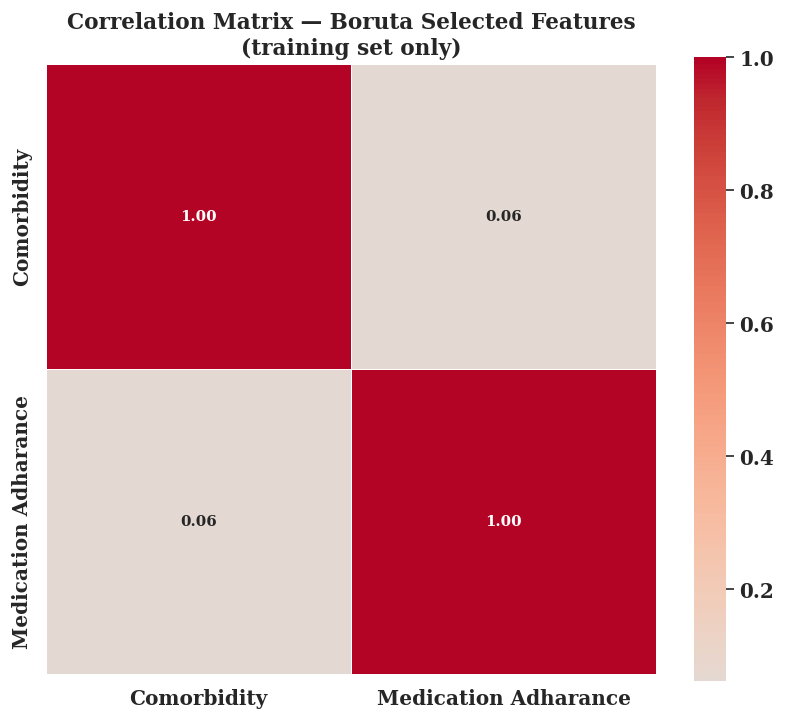

Saved: boruta_correlation_heatmap.png

BORUTA SUMMARY — for Paper
Total features evaluated : 25
Features accepted        : 2
Features tentative       : 0
Features rejected        : 23
Selected features        : ['Comorbidity', 'Medication Adharance']

Pipeline order (no leakage):
  1. Train/Test split (stratified, 80/20)
  2. Boruta fit on X_train only
  3. Feature mask applied to X_train and X_test
  4. StandardScaler fit on X_train_selected only
  5. Models trained on X_train_sel_sc
  6. Evaluated on X_test_sel_sc

Saved figures:
  boruta_feature_status.png
  boruta_feature_importance.png
  boruta_summary_pie.png
  boruta_correlation_heatmap.png


In [7]:
# ==============================================================
# BORUTA FEATURE SELECTION — Correct Pipeline (No Leakage)
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('=' * 60)
print('Boruta Feature Selection — Correct Pipeline')
print('=' * 60)

# ==============================================================
# SECTION 0 — Data Split FIRST (before Boruta)
# ==============================================================
print('\n--- Step 1: Train/Test Split (before Boruta) ---')

# ✓ Split আগে — Boruta পরে
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f'Train set : {X_train_b.shape} — Boruta will fit on this only')
print(f'Test set  : {X_test_b.shape} — untouched until evaluation')

# ==============================================================
# SECTION 1 — Boruta fit on TRAIN ONLY
# ==============================================================
print('\n--- Step 2: Boruta fit on Train set only ---')

rf_boruta = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    perc=100,               # strict selection
    alpha=0.05,
    max_iter=100,
    random_state=SEED,
    verbose=1
)

# ✓ fit ONLY on training data — no leakage
boruta_selector.fit(
    X_train_b if isinstance(X_train_b, np.ndarray) else X_train_b.values,
    y_train_b if isinstance(y_train_b, np.ndarray) else y_train_b.values
)

print('\n✓ Boruta fitting complete')

# ==============================================================
# SECTION 2 — Results
# ==============================================================
print('\n--- Step 3: Feature Selection Results ---')

# Get all column names
if hasattr(X, 'columns'):
    all_features = X.columns.tolist()
else:
    all_features = [f'Feature_{i}' for i in range(X.shape[1])]

# Boruta results
accepted  = boruta_selector.support_
tentative = boruta_selector.support_weak_
rejected  = ~accepted & ~tentative

# Build results dataframe
boruta_df = pd.DataFrame({
    'Feature'   : all_features,
    'Accepted'  : accepted,
    'Tentative' : tentative,
    'Rejected'  : rejected,
    'Ranking'   : boruta_selector.ranking_
}).sort_values('Ranking')

print(f'\nTotal features    : {len(all_features)}')
print(f'Accepted          : {accepted.sum()}')
print(f'Tentative         : {tentative.sum()}')
print(f'Rejected          : {rejected.sum()}')

print('\n--- Feature Status ---')
print(f"{'Feature':<30} {'Status':<12} {'Rank'}")
print('-' * 50)
for _, row in boruta_df.iterrows():
    if row['Accepted']:
        status = '✓ Accepted'
    elif row['Tentative']:
        status = '~ Tentative'
    else:
        status = '✗ Rejected'
    print(f"{row['Feature']:<30} {status:<12} {int(row['Ranking'])}")

# Selected features
selected_features = [f for f, a in zip(all_features, accepted) if a]
print(f'\nSelected features ({len(selected_features)}):')
for f in selected_features:
    print(f'  ✓ {f}')

# ==============================================================
# SECTION 3 — Apply mask to train and test
# ==============================================================
print('\n--- Step 4: Apply feature mask ---')

X_train_sel = boruta_selector.transform(
    X_train_b if isinstance(X_train_b, np.ndarray) else X_train_b.values
)
X_test_sel  = boruta_selector.transform(
    X_test_b if isinstance(X_test_b, np.ndarray) else X_test_b.values
)

print(f'X_train before : {X_train_b.shape}')
print(f'X_train after  : {X_train_sel.shape}')
print(f'X_test before  : {X_test_b.shape}')
print(f'X_test after   : {X_test_sel.shape}')

# Scale after selection
scaler_b      = StandardScaler()
X_train_sel_sc = scaler_b.fit_transform(X_train_sel)   # fit on train
X_test_sel_sc  = scaler_b.transform(X_test_sel)         # transform test

print('✓ Scaling applied (fit on train only)')

# ==============================================================
# VISUALIZATION 1 — Feature Status Bar Chart
# ==============================================================
print('\n--- Visualization 1: Feature Status ---')

colors = []
statuses = []
for _, row in boruta_df.iterrows():
    if row['Accepted']:
        colors.append('#2ecc71')
        statuses.append('Accepted')
    elif row['Tentative']:
        colors.append('#f39c12')
        statuses.append('Tentative')
    else:
        colors.append('#e74c3c')
        statuses.append('Rejected')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    boruta_df['Feature'],
    boruta_df['Ranking'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Legend
patches = [
    mpatches.Patch(color='#2ecc71', label='Accepted'),
    mpatches.Patch(color='#f39c12', label='Tentative'),
    mpatches.Patch(color='#e74c3c', label='Rejected'),
]
ax.legend(handles=patches, loc='lower right', fontsize=10)
ax.set_xlabel('Boruta Ranking (lower = more important)', fontsize=11)
ax.set_title('Boruta Feature Selection Results\n'
             '(fit on training set only — no data leakage)',
             fontsize=13)
ax.axvline(x=1, color='#2ecc71', linestyle='--',
           alpha=0.5, label='Rank 1 = Confirmed')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('boruta_feature_status.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boruta_feature_status.png')

# ==============================================================
# VISUALIZATION 2 — Feature Importance from Boruta's RF
# ==============================================================
print('\n--- Visualization 2: Feature Importance ---')

# Refit RF on selected features to get importance
rf_importance = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)
rf_importance.fit(X_train_sel_sc, y_train_b)

importance_df = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(selected_features) * 0.5)))
bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='steelblue',
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Feature Importance — Boruta Selected Features\n'
             '(Random Forest, trained on selected features)',
             fontsize=13)
plt.tight_layout()
plt.savefig('boruta_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boruta_feature_importance.png')

# ==============================================================
# VISUALIZATION 3 — Accepted vs Rejected Summary Pie
# ==============================================================
print('\n--- Visualization 3: Selection Summary Pie ---')

sizes  = [accepted.sum(), tentative.sum(), rejected.sum()]
labels = [f'Accepted\n(n={accepted.sum()})',
          f'Tentative\n(n={tentative.sum()})',
          f'Rejected\n(n={rejected.sum()})']
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
explode    = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors_pie,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax.set_title('Boruta Feature Selection Summary\n'
             f'(Total features: {len(all_features)})',
             fontsize=13)
plt.tight_layout()
plt.savefig('boruta_summary_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boruta_summary_pie.png')

# ==============================================================
# VISUALIZATION 4 — Heatmap: Selected Feature Correlation
# ==============================================================
print('\n--- Visualization 4: Selected Feature Correlation ---')

X_train_sel_df = pd.DataFrame(X_train_sel_sc, columns=selected_features)
corr_matrix    = X_train_sel_df.corr()

fig, ax = plt.subplots(figsize=(max(7, len(selected_features)),
                                max(6, len(selected_features) - 1)))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Boruta Selected Features\n'
             '(training set only)',
             fontsize=13)
plt.tight_layout()
plt.savefig('boruta_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boruta_correlation_heatmap.png')

# ==============================================================
# FINAL SUMMARY
# ==============================================================
print()
print('=' * 60)
print('BORUTA SUMMARY — for Paper')
print('=' * 60)
print(f'Total features evaluated : {len(all_features)}')
print(f'Features accepted        : {accepted.sum()}')
print(f'Features tentative       : {tentative.sum()}')
print(f'Features rejected        : {rejected.sum()}')
print(f'Selected features        : {selected_features}')
print()
print('Pipeline order (no leakage):')
print('  1. Train/Test split (stratified, 80/20)')
print('  2. Boruta fit on X_train only')
print('  3. Feature mask applied to X_train and X_test')
print('  4. StandardScaler fit on X_train_selected only')
print('  5. Models trained on X_train_sel_sc')
print('  6. Evaluated on X_test_sel_sc')
print()
print('Saved figures:')
print('  boruta_feature_status.png')
print('  boruta_feature_importance.png')
print('  boruta_summary_pie.png')
print('  boruta_correlation_heatmap.png')

In [8]:
# --------------------------------------------------------------
# Drop non-clinical / demographic columns
# (red-marked variables + original confounders)
# --------------------------------------------------------------
COLS_TO_DROP = [
    # 🔴 Red-marked variables identified in image_5cabde.png
    'NCD Drug Availability',      
    'Family Types',
    'Follow Up Patient', 
    'Age',
    'Socio.Economic.Status',
    'Patterns of Health Education',
    'Marital Status',
    'Education',
    'Sex',
    'Policy',
    'Area of living',
    'Religion',
    'Occupation',
]

# Ensure naming consistency with the dataset and drop only existing columns
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in data.columns]

# Apply the drop to the main dataset
data = data.drop(columns=COLS_TO_DROP)

TARGET = 'MS_Control'
FEATURE_NAMES = [c for c in data.columns if c != TARGET]

print(f'Features remaining ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')
print(f'Missing values in filtered dataset:\n{data.isnull().sum()}')
data.shape

Features remaining (13): ['HosLevel', 'Socio Economic Status', 'BMI', 'PolyPharmacy', 'Comorbidity', 'Dietary Patterns', 'Physical Activity', 'Medication Adharance', 'Community Participation', 'Clinic Service', 'Screening', 'Health behavior monitoring', 'Communities Outreach']
Missing values in filtered dataset:
HosLevel                      0
Socio Economic Status         0
BMI                           0
PolyPharmacy                  0
MS_Control                    0
Comorbidity                   0
Dietary Patterns              0
Physical Activity             0
Medication Adharance          0
Community Participation       0
Clinic Service                0
Screening                     0
Health behavior monitoring    0
Communities Outreach          0
dtype: int64


(472, 14)

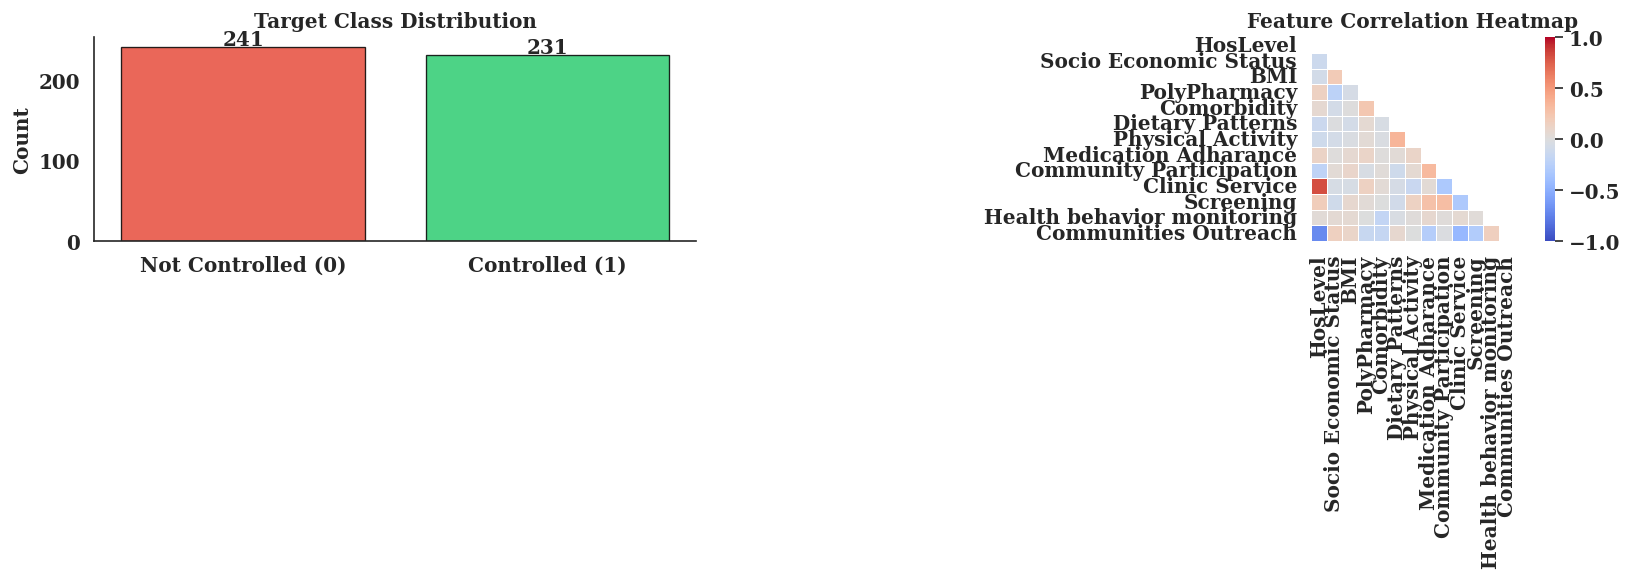

In [9]:
# --------------------------------------------------------------
# Exploratory Data Analysis
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Target class distribution ---
counts = data[TARGET].value_counts()
axes[0].bar(
    ['Not Controlled (0)', 'Controlled (1)'],
    counts.values,
    color=['#E74C3C', '#2ECC71'], edgecolor='black', alpha=0.85
)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
sns.despine(ax=axes[0])

# --- Feature correlation heatmap ---
corr = data[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[1], cmap='coolwarm',
    vmin=-1, vmax=1, annot=False, linewidths=0.3, square=True
)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Train / Test Split (80/20) & Scaling

> **Why 80/20 + CV?** With n=472, a 3-way split gives only ~71 samples in val and test — far too small for stable estimates. Instead we use a single 80/20 stratified split and evaluate hyperparameters via **5-fold CV on the training set only**. The 20% test set is touched exactly once for final reporting.

In [10]:
# --------------------------------------------------------------
# Features and target arrays
# --------------------------------------------------------------
X = data[FEATURE_NAMES].values
y = data[TARGET].values

# --------------------------------------------------------------
# Stratified 80/20 Train-Test split
#   - Test set is held out and ONLY used for final evaluation
#   - Hyperparameter tuning uses CV on X_train only
# --------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# --------------------------------------------------------------
# Feature scaling — fit ONLY on training data (no leakage)
# --------------------------------------------------------------
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --------------------------------------------------------------
# Cross-validation splitter used throughout hyperparameter tuning
# --------------------------------------------------------------
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

print(f'Total samples   : {len(X)}')
print(f'Train (80%) : {X_train_sc.shape}  class dist → {np.bincount(y_train)}')
print(f'Test  (20%) : {X_test_sc.shape}   class dist → {np.bincount(y_test)}')
print(f'CV strategy : Stratified {CV.n_splits}-fold on training set')

Total samples   : 472
Train (80%) : (377, 13)  class dist → [185 192]
Test  (20%) : (95, 13)   class dist → [46 49]
CV strategy : Stratified 10-fold on training set


In [11]:
print(pd.Series(y).value_counts())
print(pd.Series(y).value_counts(normalize=True))

1    241
0    231
Name: count, dtype: int64
1    0.510593
0    0.489407
Name: proportion, dtype: float64


In [12]:
X_train_sc

array([[ 1.28275853, -0.09594219, -1.76920763, ...,  1.06866527,
        -0.47331382, -0.69202535],
       [-1.2100248 , -0.09594219,  0.88812813, ..., -0.9357467 ,
         2.11276315,  0.80736291],
       [ 0.03636687, -1.38773519, -0.44053975, ...,  1.06866527,
        -0.47331382, -0.69202535],
       ...,
       [-1.2100248 , -0.09594219, -0.44053975, ..., -0.9357467 ,
        -0.47331382, -0.69202535],
       [ 0.03636687, -1.38773519, -1.76920763, ..., -0.9357467 ,
        -0.47331382, -0.69202535],
       [ 0.03636687, -1.38773519, -0.44053975, ...,  1.06866527,
        -0.47331382, -0.69202535]])

In [13]:
X_test_sc

array([[ 0.03636687, -1.38773519,  2.21679602, ..., -0.9357467 ,
        -0.47331382, -0.69202535],
       [ 0.03636687, -0.09594219, -0.44053975, ...,  1.06866527,
        -0.47331382, -0.69202535],
       [ 0.03636687, -1.38773519, -0.44053975, ...,  1.06866527,
        -0.47331382, -0.69202535],
       ...,
       [ 0.03636687, -1.38773519, -1.76920763, ..., -0.9357467 ,
        -0.47331382, -0.69202535],
       [-1.2100248 ,  1.19585082, -0.44053975, ..., -0.9357467 ,
        -0.47331382,  0.80736291],
       [ 1.28275853, -0.09594219,  0.88812813, ...,  1.06866527,
         2.11276315, -0.69202535]])

## Section 4 — Shared Evaluation Utility

In [14]:
# ==============================================================
# evaluate_model() — called identically for every model
# ==============================================================
def evaluate_model(name, y_true, y_pred, y_proba):
    """
    Compute and print Accuracy, ROC-AUC, F1, Precision, Recall, Brier.
    Returns a dict for the comparison table.
    """
    acc   = accuracy_score(y_true, y_pred)
    roc   = roc_auc_score(y_true, y_proba)
    f1    = f1_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_proba)

    print(f'\n--- {name} ---')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  Brier     : {brier:.4f}')
    print(classification_report(y_true, y_pred,
                                target_names=['Not Ctrl', 'Ctrl']))
    return dict(acc=acc, auc=roc, f1=f1,
                precision=prec, recall=rec, brier=brier)


# ==============================================================
# Global stores — populated after each model
# ==============================================================
results     = {}   # {model_name: {'cv_auc': float, 'train': dict, 'test': dict}}
test_probas = {}   # {model_name: np.ndarray of proba on test set}
shap_info   = {}   # {model_name: {'explainer': ..., 'values': np.ndarray}}


# ==============================================================
# fit_and_evaluate() — shared final-model training helper
# ==============================================================
def fit_and_evaluate(model_name, clf, cv_auc):
    """
    Train `clf` on the full training set, then evaluate on
    train + test splits. Stores results in global dicts.

    Parameters
    ----------
    model_name : str
    clf        : fitted or unfitted sklearn-compatible classifier
    cv_auc     : float — best CV AUC from Bayesian tuning
    """
    clf.fit(X_train_sc, y_train)
    results[model_name] = {'cv_auc': cv_auc}

    for split, X_s, y_s in [('train', X_train_sc, y_train),
                              ('test',  X_test_sc,  y_test)]:
        pred  = clf.predict(X_s)
        proba = clf.predict_proba(X_s)[:, 1]
        results[model_name][split] = evaluate_model(
            f'{model_name} — {split}', y_s, pred, proba
        )

    test_probas[model_name] = clf.predict_proba(X_test_sc)[:, 1]
    return clf


# ==============================================================
# run_bayes_opt() — shared Bayesian tuning runner
# ==============================================================
def run_bayes_opt(space, build_fn, n_calls=40, n_initial=10):
    """
    Bayesian Optimisation over `space` using 5-fold CV ROC-AUC
    evaluated on X_train_sc / y_train only.

    Returns
    -------
    best_params : dict
    best_cv_auc : float
    """
    @use_named_args(space)
    def objective(**params):
        clf    = build_fn(**params)
        scores = cross_val_score(
                clf, X_train_sc, y_train,
                cv=CV, scoring='roc_auc',
                n_jobs=1 if hasattr(clf, 'random_seed') else -1  # CatBoost=1, others=-1
            )
        return -scores.mean()

    opt         = gp_minimize(objective, space,
                              n_calls=n_calls,
                              n_initial_points=n_initial,
                              random_state=SEED,
                              verbose=False)
    best_params = {dim.name: opt.x[i]
                   for i, dim in enumerate(space)}
    best_cv_auc = -opt.fun
    return best_params, best_cv_auc


print('Evaluation utilities ready.')

Evaluation utilities ready.


## Section 6 — MLP (scikit-learn)

Bayesian Optimisation — MLP (80 calls)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

Best CV AUC  : 0.7990
Best params  : {'layer1': np.int64(60), 'layer2': np.int64(0), 'alpha': 3.311460953550684, 'lr_init': 0.01, 'activation': np.str_('relu'), 'solver': np.str_('lbfgs'), 'max_iter': np.int64(3000)}

--- MLP — train ---
  Accuracy  : 0.8833
  ROC-AUC   : 0.9656
  F1        : 0.8848
  Precision : 0.8895
  Recall    : 0.8802
  Brier     : 0.0874
              precision    recall  f1-score   support

    Not Ctrl       0.88      0.89      0.88       185
        Ctrl       0.89      0.88      0.88       192

    accuracy                           0.88       377
   macro avg       0.88      0.88      0.88       377
weighted avg       0.88      0.88      0.88       377


--- MLP — test ---
  Accuracy  : 0.6000
  ROC-AUC   : 0.6597
  F1        : 0.6122
  Precision : 0.6122
  Recall    : 0.6122
  Brier     : 0.2605
              precision    recall  f1-score   support

    Not Ctrl       0.59      0.59      0.59        46
        Ctrl       0.61      0.61      0.61        49


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

Metric            Train       Test      Std
--------------------------------------------
AUC              0.9595     0.7692   0.0699
Accuracy         0.8927     0.7035   0.0539
F1               0.8946     0.7080   0.0593
Precision        0.8971     0.7145   0.0600
Recall           0.8921     0.7093   0.0879

--- Reportable results for paper ---
CV AUC       : 0.7692 ± 0.0699 [0.6522 – 0.8587]
CV Accuracy  : 0.7035 ± 0.0539 [0.6383 – 0.8085]
CV F1        : 0.7080 ± 0.0593 [0.5854 – 0.8085]
CV Precision : 0.7145 ± 0.0600 [0.6207 – 0.8261]
CV Recall    : 0.7093 ± 0.0879 [0.5000 – 0.7917]

Bootstrap 95% CI — AUC (1000 iterations)
MLP AUC : 0.6622  (95% CI: 0.5533 – 0.7634)

Confusion Matrix — MLP


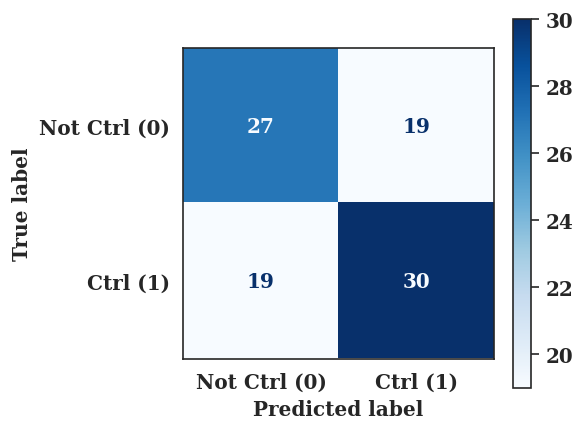


Confusion Matrix:
[[27 19]
 [19 30]]

TN=27  FP=19
FN=19  TP=30

ROC Curve — MLP with 95% CI Band


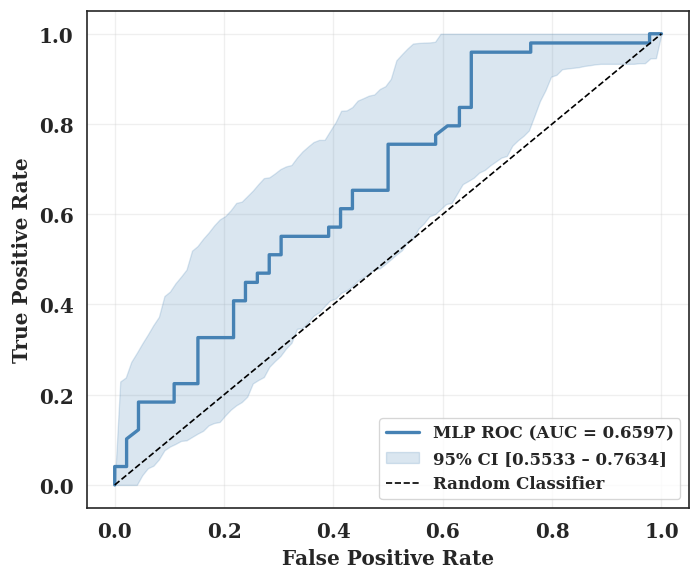


Learning Curve — MLP


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

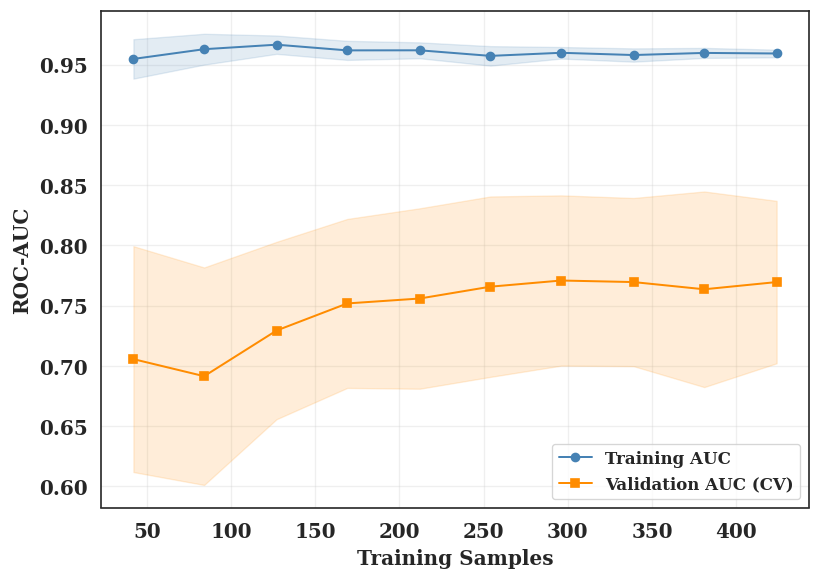


FINAL SUMMARY — MLP Reportable Results
Best Params       : {'layer1': np.int64(60), 'layer2': np.int64(0), 'alpha': 3.311460953550684, 'lr_init': 0.01, 'activation': np.str_('relu'), 'solver': np.str_('lbfgs'), 'max_iter': np.int64(3000)}
Architecture      : (np.int64(60),)

Single Split Results (train/test = 80/20):
  Train AUC       : 0.9656
  Test  AUC       : 0.6597
  Bootstrap 95% CI: [0.5533 – 0.7634]

10-Fold CV Results (primary reportable):
  AUC       : 0.7692 ± 0.0699
  Accuracy  : 0.7035 ± 0.0539
  F1        : 0.7080 ± 0.0593
  Precision : 0.7145 ± 0.0600
  Recall    : 0.7093 ± 0.0879

Saved figures:
  mlp_confusion_matrix.png
  mlp_roc_curve.png
  mlp_learning_curve.png


In [15]:
# ==============================================================
# IMPORTS — all required
# ==============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.neural_network  import MLPClassifier
from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_validate, learning_curve)
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     f1_score, precision_score,
                                     recall_score, brier_score_loss,
                                     classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.utils           import resample
from sklearn.pipeline        import Pipeline

warnings.filterwarnings('ignore')

# ==============================================================
# SECTION 0 — Bayesian Optimisation
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — MLP (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

mlp_space = [
    Integer(10,   60,  name='layer1'),
    Integer(0,    30,  name='layer2'),
    Real(0.1,   10.0,  prior='log-uniform', name='alpha'),
    Real(1e-4,  0.01,  prior='log-uniform', name='lr_init'),
    Categorical(['relu', 'tanh'],            name='activation'),
    Categorical(['lbfgs'],                   name='solver'),
    Integer(1000, 3000,                      name='max_iter'),
]

def build_mlp(layer1, layer2, alpha,
              lr_init, activation, solver, max_iter):
    hidden = tuple(v for v in [layer1, layer2] if v > 0)
    return MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=alpha,
        activation=activation,
        solver='lbfgs',
        max_iter=max_iter,
        random_state=SEED
    )

mlp_best, mlp_cv_auc = run_bayes_opt(
    mlp_space,
    build_mlp,
    n_calls=80
)

print(f'Best CV AUC  : {mlp_cv_auc:.4f}')
print(f'Best params  : {mlp_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
mlp_hidden = tuple(
    v for v in [mlp_best['layer1'],
                mlp_best['layer2']] if v > 0
)

mlp_final = MLPClassifier(
    hidden_layer_sizes=mlp_hidden,
    alpha=mlp_best['alpha'],
    activation=mlp_best['activation'],
    solver='lbfgs',
    max_iter=int(mlp_best['max_iter']),
    random_state=SEED
)

mlp_final.fit(X_train_sc, y_train)
mlp_model = fit_and_evaluate('MLP', mlp_final, mlp_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — MLP')
print('=' * 60)

seed_results = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc       = StandardScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)

    seed_model = MLPClassifier(
        hidden_layer_sizes=mlp_hidden,
        alpha=mlp_best['alpha'],
        activation=mlp_best['activation'],
        solver='lbfgs',
        max_iter=int(mlp_best['max_iter']),
        random_state=SEED
    )
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df = pd.DataFrame(seed_results)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df['test_auc'].mean():.4f} "
      f"± {seed_df['test_auc'].std():.4f}  "
      f"[min={seed_df['test_auc'].min():.4f}, "
      f"max={seed_df['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df['test_acc'].mean():.4f} "
      f"± {seed_df['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df['test_f1'].mean():.4f} "
      f"± {seed_df['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df['gap'].mean():.4f} "
      f"± {seed_df['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — MLP (reportable result)')
print('=' * 60)

# Pipeline — scaler inside CV prevents leakage
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=mlp_hidden,
        alpha=mlp_best['alpha'],
        activation=mlp_best['activation'],
        solver='lbfgs',
        max_iter=int(mlp_best['max_iter']),
        random_state=SEED
    ))
])

cv_report = cross_validate(
    mlp_pipe, X, y,          # raw X — pipeline handles scaling
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}
for label, key in cv_metrics.items():
    tr  = cv_report[f'train_{key}'].mean()
    te  = cv_report[f'test_{key}'].mean()
    std = cv_report[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te  = cv_report[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% Confidence Interval on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs = []
    rng  = np.random.RandomState(seed)
    y_te = np.array(y_te)
    for _ in range(n_bootstrap):
        idx      = resample(range(len(y_te)), random_state=rng)
        y_bs     = y_te[idx]
        prob_bs  = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

mean_auc, lower, upper = bootstrap_auc_ci(mlp_final, X_test_sc, y_test)
print(f"MLP AUC : {mean_auc:.4f}  (95% CI: {lower:.4f} – {upper:.4f})")

# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — MLP')
print('=' * 60)

y_pred = mlp_final.predict(X_test_sc)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('', fontsize=12)
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nTN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")

# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — MLP with 95% CI Band')
print('=' * 60)

# Main ROC
y_prob       = mlp_final.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _  = roc_curve(y_test, y_prob)
roc_auc_val  = auc(fpr, tpr)

# Bootstrap ROC for CI band
n_bootstrap  = 1000
tprs_boot    = []
base_fpr     = np.linspace(0, 1, 100)
rng          = np.random.RandomState(SEED)
y_test_arr   = np.array(y_test)

for _ in range(n_bootstrap):
    idx      = resample(range(len(y_test_arr)), random_state=rng)
    y_bs     = y_test_arr[idx]
    prob_bs  = y_prob[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot.append(tpr_interp)

tprs_boot  = np.array(tprs_boot)
mean_tpr   = tprs_boot.mean(axis=0)
lower_tpr  = np.percentile(tprs_boot, 2.5,  axis=0)
upper_tpr  = np.percentile(tprs_boot, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'MLP ROC (AUC = {roc_auc_val:.4f})')
ax.fill_between(base_fpr, lower_tpr, upper_tpr,
                alpha=0.2, color='steelblue',
                label=f'95% CI [{lower:.4f} – {upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 7 — Learning / Training Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — MLP')
print('=' * 60)

train_sizes, train_scores, val_scores = learning_curve(
    mlp_pipe,                        # pipeline with scaler
    X, y,                            # raw X
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='darkorange',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — MLP Reportable Results')
print('=' * 60)
print(f"Best Params       : {mlp_best}")
print(f"Architecture      : {mlp_hidden}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : {roc_auc_score(y_train, mlp_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : {roc_auc_score(y_test,  mlp_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{lower:.4f} – {upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  mlp_confusion_matrix.png")
print(f"  mlp_roc_curve.png")
print(f"  mlp_learning_curve.png")

## Section 7 — Random Forest

In [16]:
# ==============================================================
# IMPORTS
# ==============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_validate, learning_curve)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     f1_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.utils           import resample

warnings.filterwarnings('ignore')

# ==============================================================
# SECTION 0 — Bayesian Optimisation
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — Random Forest (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

rf_space = [
    Integer(50,  500, name='n_estimators'),
    Integer(3,   20,  name='max_depth'),
    Integer(2,   20,  name='min_samples_split'),
    Integer(1,   10,  name='min_samples_leaf'),
    Real(0.5,    1.0, name='max_features'),
]

def build_rf(n_estimators, max_depth, min_samples_split,
             min_samples_leaf, max_features):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )

rf_best, rf_cv_auc = run_bayes_opt(rf_space, build_rf, n_calls=80)
print(f'Best CV AUC : {rf_cv_auc:.4f}')
print(f'Best params : {rf_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
rf_final = build_rf(**rf_best)
rf_final.fit(X_train_sc, y_train)
rf_model = fit_and_evaluate('Random Forest', rf_final, rf_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — Random Forest')
print('=' * 60)

seed_results_rf = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    seed_model = build_rf(**rf_best)
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results_rf.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df_rf = pd.DataFrame(seed_results_rf)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df_rf['test_auc'].mean():.4f} "
      f"± {seed_df_rf['test_auc'].std():.4f}  "
      f"[min={seed_df_rf['test_auc'].min():.4f}, "
      f"max={seed_df_rf['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df_rf['test_acc'].mean():.4f} "
      f"± {seed_df_rf['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df_rf['test_f1'].mean():.4f} "
      f"± {seed_df_rf['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df_rf['gap'].mean():.4f} "
      f"± {seed_df_rf['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — Random Forest (reportable result)')
print('=' * 60)

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators    = int(rf_best['n_estimators']),
        max_depth       = int(rf_best['max_depth']),
        min_samples_split = int(rf_best['min_samples_split']),
        min_samples_leaf  = int(rf_best['min_samples_leaf']),
        max_features    = rf_best['max_features'],
        class_weight    = 'balanced',
        random_state    = SEED,
        n_jobs          = -1
    ))
])

cv_report_rf = cross_validate(
    rf_pipe, X, y,
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
for label, key in cv_metrics.items():
    tr  = cv_report_rf[f'train_{key}'].mean()
    te  = cv_report_rf[f'test_{key}'].mean()
    std = cv_report_rf[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te = cv_report_rf[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% CI on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs    = []
    rng     = np.random.RandomState(seed)
    y_te    = np.array(y_te)
    for _ in range(n_bootstrap):
        idx     = resample(range(len(y_te)), random_state=rng)
        y_bs    = y_te[idx]
        prob_bs = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

rf_mean_auc, rf_lower, rf_upper = bootstrap_auc_ci(
    rf_final, X_test_sc, y_test
)
print(f"RF AUC : {rf_mean_auc:.4f}  (95% CI: {rf_lower:.4f} – {rf_upper:.4f})")

Bayesian Optimisation — Random Forest (80 calls)
Best CV AUC : 0.7886
Best params : {'n_estimators': np.int64(500), 'max_depth': np.int64(7), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(1), 'max_features': 0.5631246813954128}

--- Random Forest — train ---
  Accuracy  : 0.9019
  ROC-AUC   : 0.9737
  F1        : 0.9044
  Precision : 0.8974
  Recall    : 0.9115
  Brier     : 0.0931
              precision    recall  f1-score   support

    Not Ctrl       0.91      0.89      0.90       185
        Ctrl       0.90      0.91      0.90       192

    accuracy                           0.90       377
   macro avg       0.90      0.90      0.90       377
weighted avg       0.90      0.90      0.90       377


--- Random Forest — test ---
  Accuracy  : 0.6947
  ROC-AUC   : 0.7347
  F1        : 0.7010
  Precision : 0.7083
  Recall    : 0.6939
  Brier     : 0.2087
              precision    recall  f1-score   support

    Not Ctrl       0.68      0.70      0.69        46
      


Confusion Matrix — Random Forest


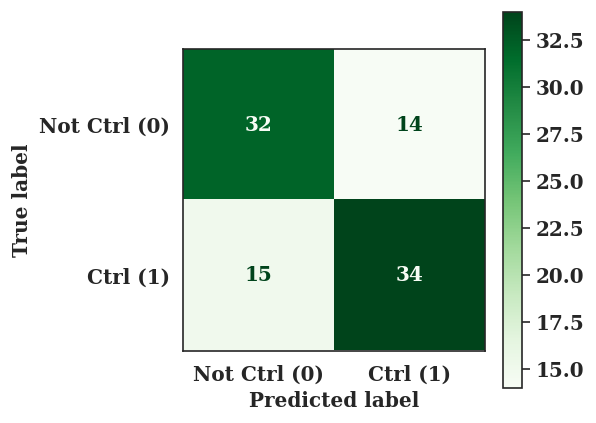


Confusion Matrix:
[[32 14]
 [15 34]]

TN=32  FP=14
FN=15  TP=34


In [17]:
# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — Random Forest')
print('=' * 60)

y_pred_rf = rf_final.predict(X_test_sc)
cm_rf     = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('',
             fontsize=11)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:\n{cm_rf}")
print(f"\nTN={cm_rf[0,0]}  FP={cm_rf[0,1]}")
print(f"FN={cm_rf[1,0]}  TP={cm_rf[1,1]}")



ROC Curve — Random Forest with 95% CI Band


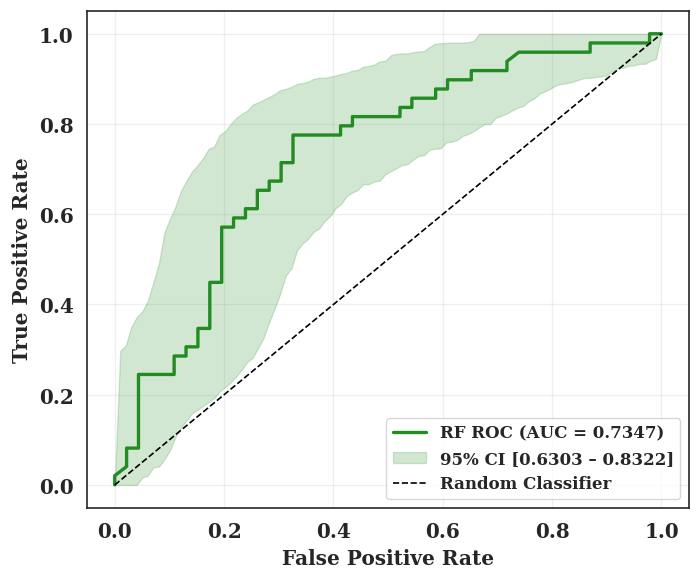

In [18]:
# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — Random Forest with 95% CI Band')
print('=' * 60)

y_prob_rf      = rf_final.predict_proba(X_test_sc)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf     = auc(fpr_rf, tpr_rf)

# Bootstrap ROC CI band
tprs_boot_rf   = []
base_fpr       = np.linspace(0, 1, 100)
rng            = np.random.RandomState(SEED)
y_test_arr     = np.array(y_test)

for _ in range(1000):
    idx      = resample(range(len(y_test_arr)), random_state=rng)
    y_bs     = y_test_arr[idx]
    prob_bs  = y_prob_rf[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot_rf.append(tpr_interp)

tprs_boot_rf = np.array(tprs_boot_rf)
mean_tpr_rf  = tprs_boot_rf.mean(axis=0)
lower_tpr_rf = np.percentile(tprs_boot_rf, 2.5,  axis=0)
upper_tpr_rf = np.percentile(tprs_boot_rf, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2,
        label=f'RF ROC (AUC = {roc_auc_rf:.4f})')
ax.fill_between(base_fpr, lower_tpr_rf, upper_tpr_rf,
                alpha=0.2, color='forestgreen',
                label=f'95% CI [{rf_lower:.4f} – {rf_upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()



Learning Curve — Random Forest


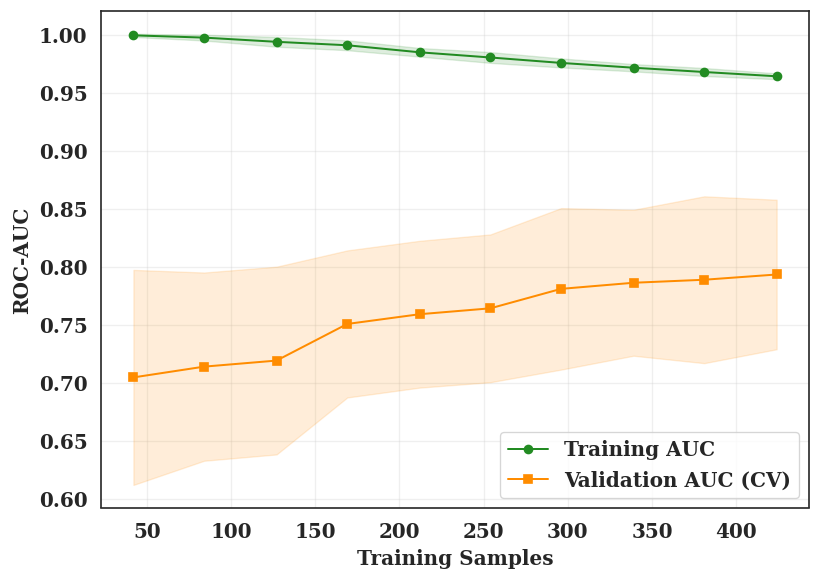

In [19]:
# ==============================================================
# SECTION 7 — Learning Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — Random Forest')
print('=' * 60)

train_sizes, train_scores_rf, val_scores_rf = learning_curve(
    rf_pipe, X, y,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=SEED
)

train_mean_rf = train_scores_rf.mean(axis=1)
train_std_rf  = train_scores_rf.std(axis=1)
val_mean_rf   = val_scores_rf.mean(axis=1)
val_std_rf    = val_scores_rf.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean_rf, 'o-', color='forestgreen',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean_rf - train_std_rf,
                train_mean_rf + train_std_rf,
                alpha=0.15, color='forestgreen')
ax.plot(train_sizes, val_mean_rf, 's-', color='darkorange',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean_rf - val_std_rf,
                val_mean_rf + val_std_rf,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('',
             fontsize=13)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rf_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — Random Forest Reportable Results')
print('=' * 60)
print(f"Best Params  : {rf_best}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : "
      f"{roc_auc_score(y_train, rf_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : "
      f"{roc_auc_score(y_test,  rf_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{rf_lower:.4f} – {rf_upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report_rf[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  rf_confusion_matrix.png")
print(f"  rf_roc_curve.png")
print(f"  rf_learning_curve.png")


FINAL SUMMARY — Random Forest Reportable Results
Best Params  : {'n_estimators': np.int64(500), 'max_depth': np.int64(7), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(1), 'max_features': 0.5631246813954128}

Single Split Results (train/test = 80/20):
  Train AUC       : 0.9737
  Test  AUC       : 0.7347
  Bootstrap 95% CI: [0.6303 – 0.8322]

10-Fold CV Results (primary reportable):
  AUC       : 0.7887 ± 0.0623
  Accuracy  : 0.7286 ± 0.0604
  F1        : 0.7345 ± 0.0656
  Precision : 0.7330 ± 0.0564
  Recall    : 0.7425 ± 0.0951

Saved figures:
  rf_confusion_matrix.png
  rf_roc_curve.png
  rf_learning_curve.png


## Section 8 — CatBoost

Bayesian Optimisation — CatBoost (80 calls)
Best CV AUC : 0.8010
Best params : {'iterations': np.int64(703), 'learning_rate': 0.010057305360344253, 'depth': np.int64(3), 'l2_leaf_reg': 8.474802175139683, 'subsample': 0.9395181878804881}

--- CatBoost — train ---
  Accuracy  : 0.8090
  ROC-AUC   : 0.8968
  F1        : 0.8075
  Precision : 0.8297
  Recall    : 0.7865
  Brier     : 0.1409
              precision    recall  f1-score   support

    Not Ctrl       0.79      0.83      0.81       185
        Ctrl       0.83      0.79      0.81       192

    accuracy                           0.81       377
   macro avg       0.81      0.81      0.81       377
weighted avg       0.81      0.81      0.81       377


--- CatBoost — test ---
  Accuracy  : 0.6000
  ROC-AUC   : 0.6943
  F1        : 0.5581
  Precision : 0.6486
  Recall    : 0.4898
  Brier     : 0.2305
              precision    recall  f1-score   support

    Not Ctrl       0.57      0.72      0.63        46
        Ctrl       0.65 

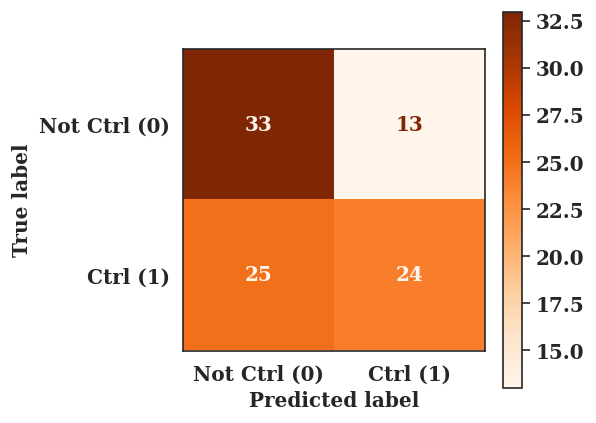


Confusion Matrix:
[[33 13]
 [25 24]]

TN=33  FP=13
FN=25  TP=24

ROC Curve — CatBoost with 95% CI Band


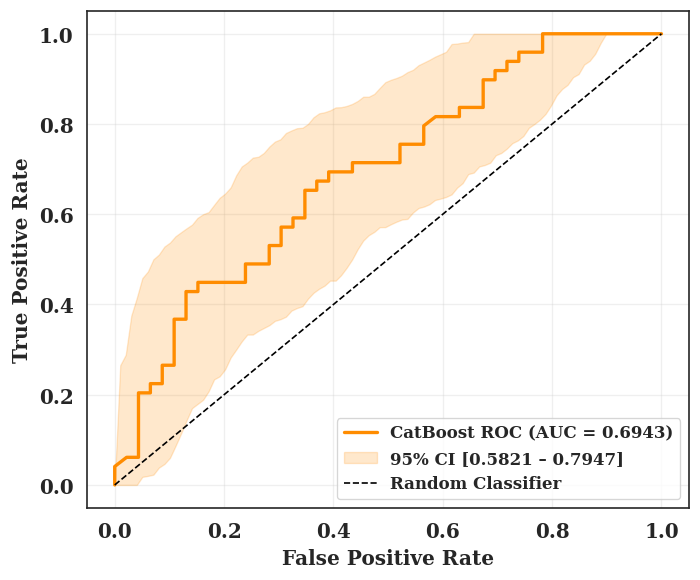


Learning Curve — CatBoost


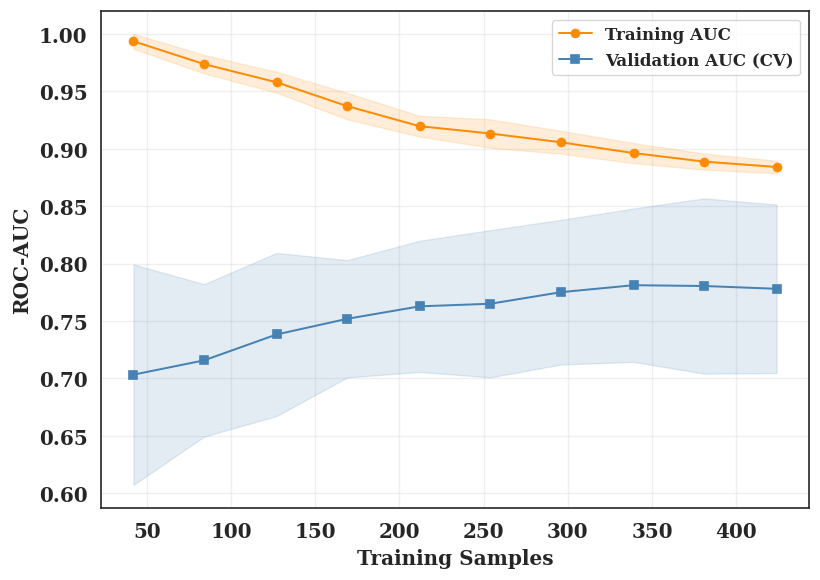


FINAL SUMMARY — CatBoost Reportable Results
Best Params  : {'iterations': np.int64(703), 'learning_rate': 0.010057305360344253, 'depth': np.int64(3), 'l2_leaf_reg': 8.474802175139683, 'subsample': 0.9395181878804881}

Single Split Results (train/test = 80/20):
  Train AUC       : 0.8968
  Test  AUC       : 0.6943
  Bootstrap 95% CI: [0.5821 – 0.7947]

10-Fold CV Results (primary reportable):
  AUC       : 0.7800 ± 0.0719
  Accuracy  : 0.7225 ± 0.0513
  F1        : 0.7189 ± 0.0631
  Precision : 0.7426 ± 0.0531
  Recall    : 0.7057 ± 0.1018

Saved figures:
  cb_confusion_matrix.png
  cb_roc_curve.png
  cb_learning_curve.png


In [21]:
# ==============================================================
# SECTION 0 — Bayesian Optimisation — CatBoost
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — CatBoost (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

cb_space = [
    Integer(100, 800,  name='iterations'),
    Real(0.01,   0.3,  prior='log-uniform', name='learning_rate'),
    Integer(3,   10,   name='depth'),
    Real(1.0,    10.0, name='l2_leaf_reg'),
    Real(0.5,    1.0,  name='subsample'),
]

# ✓ all types explicitly cast — fixes sklearn clone error
def build_catboost(iterations, learning_rate, depth,
                   l2_leaf_reg, subsample):
    return CatBoostClassifier(
        iterations=int(iterations),
        learning_rate=float(learning_rate),
        depth=int(depth),
        l2_leaf_reg=float(l2_leaf_reg),
        subsample=float(subsample),
        auto_class_weights='Balanced',
        random_seed=SEED,
        verbose=0
    )

# Custom bayes opt for CatBoost — n_jobs=1 to avoid conflict
@use_named_args(cb_space)
def cb_objective(**params):
    clf    = build_catboost(**params)
    scores = cross_val_score(
        clf, X_train_sc, y_train,
        cv=CV, scoring='roc_auc',
        n_jobs=1        # ✓ CatBoost handles parallelism internally
    )
    return -scores.mean()

cb_opt = gp_minimize(
    cb_objective, cb_space,
    n_calls=80,
    n_initial_points=10,
    random_state=SEED,
    verbose=False
)

cb_best    = {dim.name: cb_opt.x[i]
              for i, dim in enumerate(cb_space)}
cb_cv_auc  = -cb_opt.fun

print(f'Best CV AUC : {cb_cv_auc:.4f}')
print(f'Best params : {cb_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
cb_final = build_catboost(**cb_best)
cb_final.fit(X_train_sc, y_train)
cb_model = fit_and_evaluate('CatBoost', cb_final, cb_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — CatBoost')
print('=' * 60)

seed_results_cb = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    seed_model = build_catboost(**cb_best)
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results_cb.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df_cb = pd.DataFrame(seed_results_cb)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df_cb['test_auc'].mean():.4f} "
      f"± {seed_df_cb['test_auc'].std():.4f}  "
      f"[min={seed_df_cb['test_auc'].min():.4f}, "
      f"max={seed_df_cb['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df_cb['test_acc'].mean():.4f} "
      f"± {seed_df_cb['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df_cb['test_f1'].mean():.4f} "
      f"± {seed_df_cb['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df_cb['gap'].mean():.4f} "
      f"± {seed_df_cb['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — CatBoost (reportable result)')
print('=' * 60)

scaler_full  = StandardScaler()
X_scaled_all = scaler_full.fit_transform(X)

cb_cv_model  = build_catboost(**cb_best)

cv_report_cb = cross_validate(
    cb_cv_model,
    X_scaled_all, y,
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=1        # ✓ CatBoost — no parallel
)

cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
for label, key in cv_metrics.items():
    tr  = cv_report_cb[f'train_{key}'].mean()
    te  = cv_report_cb[f'test_{key}'].mean()
    std = cv_report_cb[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te = cv_report_cb[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% CI on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs = []
    rng  = np.random.RandomState(seed)
    y_te = np.array(y_te)
    for _ in range(n_bootstrap):
        idx     = resample(range(len(y_te)), random_state=rng)
        y_bs    = y_te[idx]
        prob_bs = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

cb_mean_auc, cb_lower, cb_upper = bootstrap_auc_ci(
    cb_final, X_test_sc, y_test
)
print(f"CatBoost AUC : {cb_mean_auc:.4f}  "
      f"(95% CI: {cb_lower:.4f} – {cb_upper:.4f})")

# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — CatBoost')
print('=' * 60)

y_pred_cb = cb_final.predict(X_test_sc)
cm_cb     = confusion_matrix(y_test, y_pred_cb)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm_cb,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title('',
             fontsize=11)
plt.tight_layout()
plt.savefig('cb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:\n{cm_cb}")
print(f"\nTN={cm_cb[0,0]}  FP={cm_cb[0,1]}")
print(f"FN={cm_cb[1,0]}  TP={cm_cb[1,1]}")

# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — CatBoost with 95% CI Band')
print('=' * 60)

y_prob_cb         = cb_final.predict_proba(X_test_sc)[:, 1]
fpr_cb, tpr_cb, _ = roc_curve(y_test, y_prob_cb)
roc_auc_cb        = auc(fpr_cb, tpr_cb)

tprs_boot_cb = []
base_fpr     = np.linspace(0, 1, 100)
rng          = np.random.RandomState(SEED)
y_test_arr   = np.array(y_test)

for _ in range(1000):
    idx     = resample(range(len(y_test_arr)), random_state=rng)
    y_bs    = y_test_arr[idx]
    prob_bs = y_prob_cb[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot_cb.append(tpr_interp)

tprs_boot_cb = np.array(tprs_boot_cb)
lower_tpr_cb = np.percentile(tprs_boot_cb, 2.5,  axis=0)
upper_tpr_cb = np.percentile(tprs_boot_cb, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_cb, tpr_cb, color='darkorange', lw=2,
        label=f'CatBoost ROC (AUC = {roc_auc_cb:.4f})')
ax.fill_between(base_fpr, lower_tpr_cb, upper_tpr_cb,
                alpha=0.2, color='darkorange',
                label=f'95% CI [{cb_lower:.4f} – {cb_upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cb_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 7 — Learning Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — CatBoost')
print('=' * 60)

train_sizes, train_scores_cb, val_scores_cb = learning_curve(
    build_catboost(**cb_best),
    X_scaled_all, y,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1,
    shuffle=True,
    random_state=SEED
)

train_mean_cb = train_scores_cb.mean(axis=1)
train_std_cb  = train_scores_cb.std(axis=1)
val_mean_cb   = val_scores_cb.mean(axis=1)
val_std_cb    = val_scores_cb.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean_cb, 'o-', color='darkorange',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean_cb - train_std_cb,
                train_mean_cb + train_std_cb,
                alpha=0.15, color='darkorange')
ax.plot(train_sizes, val_mean_cb, 's-', color='steelblue',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean_cb - val_std_cb,
                val_mean_cb + val_std_cb,
                alpha=0.15, color='steelblue')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cb_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — CatBoost Reportable Results')
print('=' * 60)
print(f"Best Params  : {cb_best}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : "
      f"{roc_auc_score(y_train, cb_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : "
      f"{roc_auc_score(y_test,  cb_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{cb_lower:.4f} – {cb_upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report_cb[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  cb_confusion_matrix.png")
print(f"  cb_roc_curve.png")
print(f"  cb_learning_curve.png")

## Section 9 — XGBoost

Bayesian Optimisation — XGBoost (80 calls)
Best CV AUC : 0.7942
Best params : {'n_estimators': np.int64(50), 'learning_rate': 0.16658467119625256, 'max_depth': np.int64(6), 'subsample': 0.5, 'colsample_bytree': 0.5, 'gamma': 1.4809636708471996, 'min_child_weight': 1.0, 'reg_alpha': 0.09209087570524754, 'reg_lambda': 0.05839261599425036}

--- XGBoost — train ---
  Accuracy  : 0.7958
  ROC-AUC   : 0.8832
  F1        : 0.7958
  Precision : 0.8108
  Recall    : 0.7812
  Brier     : 0.1435
              precision    recall  f1-score   support

    Not Ctrl       0.78      0.81      0.80       185
        Ctrl       0.81      0.78      0.80       192

    accuracy                           0.80       377
   macro avg       0.80      0.80      0.80       377
weighted avg       0.80      0.80      0.80       377


--- XGBoost — test ---
  Accuracy  : 0.6105
  ROC-AUC   : 0.6713
  F1        : 0.5747
  Precision : 0.6579
  Recall    : 0.5102
  Brier     : 0.2427
              precision    recall

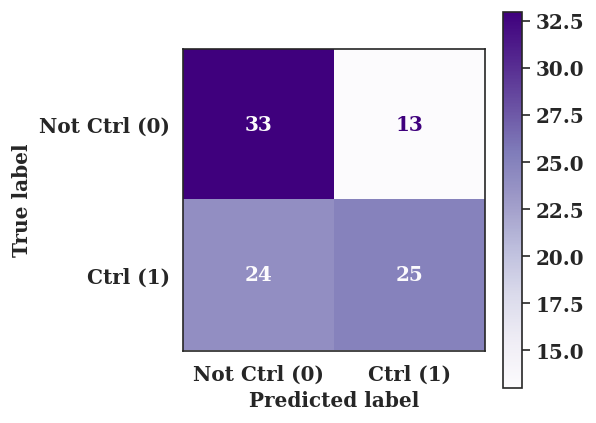


Confusion Matrix:
[[33 13]
 [24 25]]

TN=33  FP=13
FN=24  TP=25

ROC Curve — XGBoost with 95% CI Band


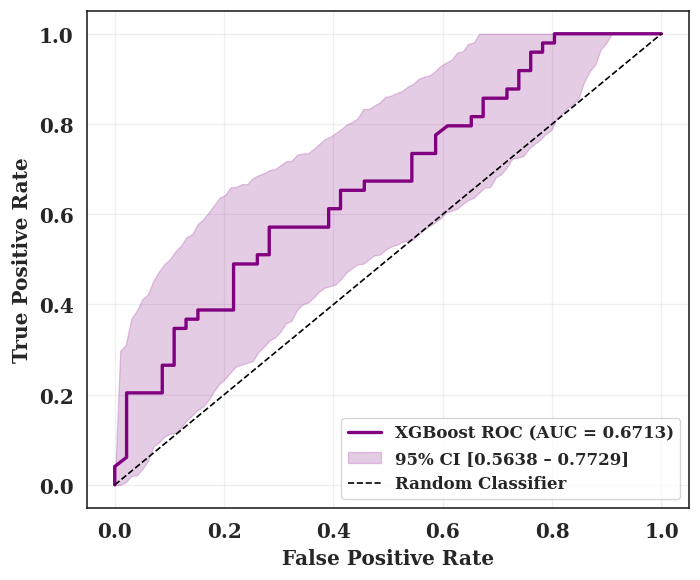


Learning Curve — XGBoost


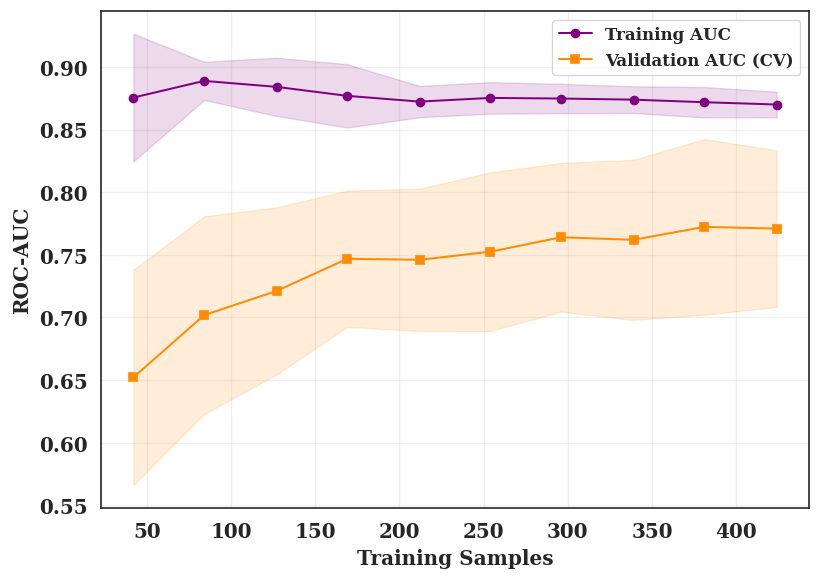


FINAL SUMMARY — XGBoost Reportable Results
Best Params  : {'n_estimators': np.int64(50), 'learning_rate': 0.16658467119625256, 'max_depth': np.int64(6), 'subsample': 0.5, 'colsample_bytree': 0.5, 'gamma': 1.4809636708471996, 'min_child_weight': 1.0, 'reg_alpha': 0.09209087570524754, 'reg_lambda': 0.05839261599425036}

Single Split Results (train/test = 80/20):
  Train AUC       : 0.8832
  Test  AUC       : 0.6713
  Bootstrap 95% CI: [0.5638 – 0.7729]

10-Fold CV Results (primary reportable):
  AUC       : 0.7697 ± 0.0780
  Accuracy  : 0.7033 ± 0.0620
  F1        : 0.7074 ± 0.0672
  Precision : 0.7106 ± 0.0549
  Recall    : 0.7097 ± 0.0981

Saved figures:
  xgb_confusion_matrix.png
  xgb_roc_curve.png
  xgb_learning_curve.png


In [22]:
# ==============================================================
# IMPORTS
# ==============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_validate, learning_curve)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     f1_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.utils           import resample

warnings.filterwarnings('ignore')

# ==============================================================
# SECTION 0 — Bayesian Optimisation
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — XGBoost (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

xgb_space = [
    Integer(50,  600,  name='n_estimators'),
    Real(0.01,   0.3,  prior='log-uniform', name='learning_rate'),
    Integer(3,   10,   name='max_depth'),
    Real(0.5,    1.0,  name='subsample'),
    Real(0.5,    1.0,  name='colsample_bytree'),
    Real(0.0,    5.0,  name='gamma'),
    Real(1.0,    10.0, name='min_child_weight'),
    Real(0.0,    1.0,  name='reg_alpha'),
    Real(0.0,    2.0,  name='reg_lambda'),
]

# ✓ all types explicitly cast — fixes sklearn clone error
def build_xgb(n_estimators, learning_rate, max_depth, subsample,
              colsample_bytree, gamma, min_child_weight,
              reg_alpha, reg_lambda):
    return xgb.XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        gamma=float(gamma),
        min_child_weight=float(min_child_weight),
        reg_alpha=float(reg_alpha),
        reg_lambda=float(reg_lambda),
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    )

xgb_best, xgb_cv_auc = run_bayes_opt(xgb_space, build_xgb, n_calls=80)
print(f'Best CV AUC : {xgb_cv_auc:.4f}')
print(f'Best params : {xgb_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
xgb_final = build_xgb(**xgb_best)
xgb_final.fit(X_train_sc, y_train)
xgb_model = fit_and_evaluate('XGBoost', xgb_final, xgb_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — XGBoost')
print('=' * 60)

seed_results_xgb = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    seed_model = build_xgb(**xgb_best)
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results_xgb.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df_xgb = pd.DataFrame(seed_results_xgb)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df_xgb['test_auc'].mean():.4f} "
      f"± {seed_df_xgb['test_auc'].std():.4f}  "
      f"[min={seed_df_xgb['test_auc'].min():.4f}, "
      f"max={seed_df_xgb['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df_xgb['test_acc'].mean():.4f} "
      f"± {seed_df_xgb['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df_xgb['test_f1'].mean():.4f} "
      f"± {seed_df_xgb['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df_xgb['gap'].mean():.4f} "
      f"± {seed_df_xgb['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — XGBoost (reportable result)')
print('=' * 60)

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(
        n_estimators=int(xgb_best['n_estimators']),
        learning_rate=float(xgb_best['learning_rate']),
        max_depth=int(xgb_best['max_depth']),
        subsample=float(xgb_best['subsample']),
        colsample_bytree=float(xgb_best['colsample_bytree']),
        gamma=float(xgb_best['gamma']),
        min_child_weight=float(xgb_best['min_child_weight']),
        reg_alpha=float(xgb_best['reg_alpha']),
        reg_lambda=float(xgb_best['reg_lambda']),
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    ))
])

cv_report_xgb = cross_validate(
    xgb_pipe, X, y,
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
for label, key in cv_metrics.items():
    tr  = cv_report_xgb[f'train_{key}'].mean()
    te  = cv_report_xgb[f'test_{key}'].mean()
    std = cv_report_xgb[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te = cv_report_xgb[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% CI on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs = []
    rng  = np.random.RandomState(seed)
    y_te = np.array(y_te)
    for _ in range(n_bootstrap):
        idx     = resample(range(len(y_te)), random_state=rng)
        y_bs    = y_te[idx]
        prob_bs = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

xgb_mean_auc, xgb_lower, xgb_upper = bootstrap_auc_ci(
    xgb_final, X_test_sc, y_test
)
print(f"XGBoost AUC : {xgb_mean_auc:.4f}  "
      f"(95% CI: {xgb_lower:.4f} – {xgb_upper:.4f})")

# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — XGBoost')
print('=' * 60)

y_pred_xgb = xgb_final.predict(X_test_sc)
cm_xgb     = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='Purples')
ax.set_title('',
             fontsize=11)
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:\n{cm_xgb}")
print(f"\nTN={cm_xgb[0,0]}  FP={cm_xgb[0,1]}")
print(f"FN={cm_xgb[1,0]}  TP={cm_xgb[1,1]}")

# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — XGBoost with 95% CI Band')
print('=' * 60)

y_prob_xgb          = xgb_final.predict_proba(X_test_sc)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb          = auc(fpr_xgb, tpr_xgb)

tprs_boot_xgb = []
base_fpr      = np.linspace(0, 1, 100)
rng           = np.random.RandomState(SEED)
y_test_arr    = np.array(y_test)

for _ in range(1000):
    idx     = resample(range(len(y_test_arr)), random_state=rng)
    y_bs    = y_test_arr[idx]
    prob_bs = y_prob_xgb[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot_xgb.append(tpr_interp)

tprs_boot_xgb = np.array(tprs_boot_xgb)
lower_tpr_xgb = np.percentile(tprs_boot_xgb, 2.5,  axis=0)
upper_tpr_xgb = np.percentile(tprs_boot_xgb, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_xgb, tpr_xgb, color='purple', lw=2,
        label=f'XGBoost ROC (AUC = {roc_auc_xgb:.4f})')
ax.fill_between(base_fpr, lower_tpr_xgb, upper_tpr_xgb,
                alpha=0.2, color='purple',
                label=f'95% CI [{xgb_lower:.4f} – {xgb_upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 7 — Learning Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — XGBoost')
print('=' * 60)

train_sizes, train_scores_xgb, val_scores_xgb = learning_curve(
    xgb_pipe, X, y,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=SEED
)

train_mean_xgb = train_scores_xgb.mean(axis=1)
train_std_xgb  = train_scores_xgb.std(axis=1)
val_mean_xgb   = val_scores_xgb.mean(axis=1)
val_std_xgb    = val_scores_xgb.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean_xgb, 'o-', color='purple',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean_xgb - train_std_xgb,
                train_mean_xgb + train_std_xgb,
                alpha=0.15, color='purple')
ax.plot(train_sizes, val_mean_xgb, 's-', color='darkorange',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean_xgb - val_std_xgb,
                val_mean_xgb + val_std_xgb,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — XGBoost Reportable Results')
print('=' * 60)
print(f"Best Params  : {xgb_best}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : "
      f"{roc_auc_score(y_train, xgb_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : "
      f"{roc_auc_score(y_test,  xgb_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{xgb_lower:.4f} – {xgb_upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report_xgb[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  xgb_confusion_matrix.png")
print(f"  xgb_roc_curve.png")
print(f"  xgb_learning_curve.png")

## Section 10 — LightGBM

Bayesian Optimisation — LightGBM (80 calls)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best CV AUC : 0.7937
Best params : {'n_estimators': np.int64(543), 'learning_rate': 0.2346691807436847, 'num_leaves': np.int64(111), 'min_child_samples': np.int64(47), 'subsample': 0.5433270753463759, 'colsample_bytree': 0.9576014450486008, 'reg_alpha': 0.9971866560765537, 'reg_lambda': 0.9223939072661962}

--- LightGBM — train ---
  Accuracy  : 0.7958
  ROC-AUC   : 0.8691
  F1        : 0.7936
  Precision : 0.8177
  Recall    : 0.7708
  Brier     : 0.1482
              precision    recall  f1-score   support

    Not Ctrl       0.78      0.82      0.80       185
        Ctrl       0.82      0.77      0.79       192

    accuracy                           0.80       377
   macro avg       0.80      0.80      0.80       377
weighted avg       0.80      0.80      0.80       377


--- LightGBM — test ---
  Accuracy  : 0.5895
  ROC-AUC   : 0.6892
  F1        : 0.5714
  Precision : 0.6190
  Recall    : 0.5306
  Brier     : 0.2380
              precision    recall  f1-score   support

    Not

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Metric            Train       Test      Std
--------------------------------------------
AUC              0.8625     0.7775   0.0668
Accuracy         0.7738     0.7141   0.0500
F1               0.7705     0.7064   0.0630
Precision        0.7990     0.7421   0.0605
Recall           0.7441     0.6847   0.1039

--- Reportable results for paper ---
CV AUC       : 0.7775 ± 0.0668 [0.7020 – 0.8958]
CV Accuracy  : 0.7141 ± 0.0500 [0.6383 – 0.8085]
CV F1        : 0.7064 ± 0.0630 [0.6047 – 0.8085]
CV Precision : 0.7421 ± 0.0605 [0.6800 – 0.8571]
CV Recall    : 0.6847 ± 0.1039 [0.5000 – 0.8333]

Bootstrap 95% CI — AUC (1000 iterations)
LightGBM AUC : 0.6920  (95% CI: 0.5808 – 0.7879)

Confusion Matrix — LightGBM


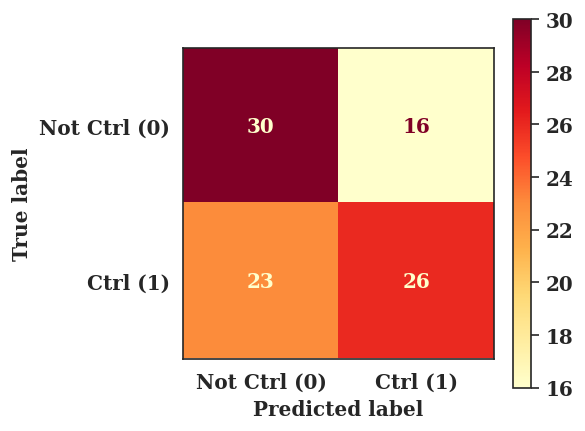


Confusion Matrix:
[[30 16]
 [23 26]]

TN=30  FP=16
FN=23  TP=26

ROC Curve — LightGBM with 95% CI Band


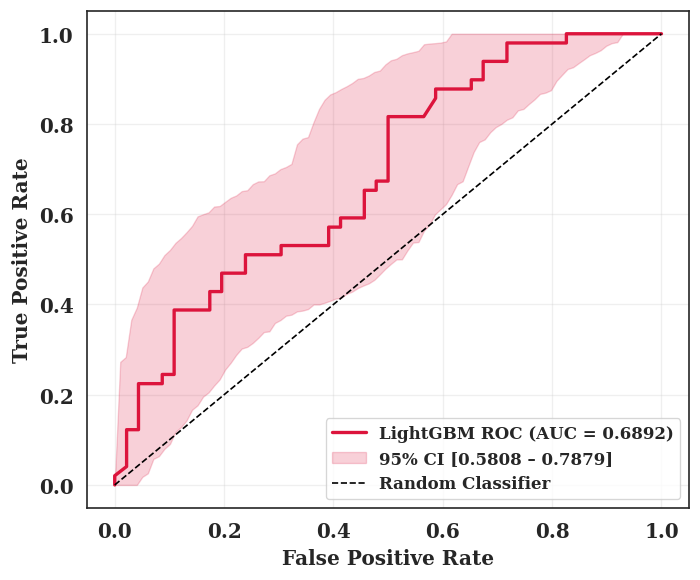


Learning Curve — LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

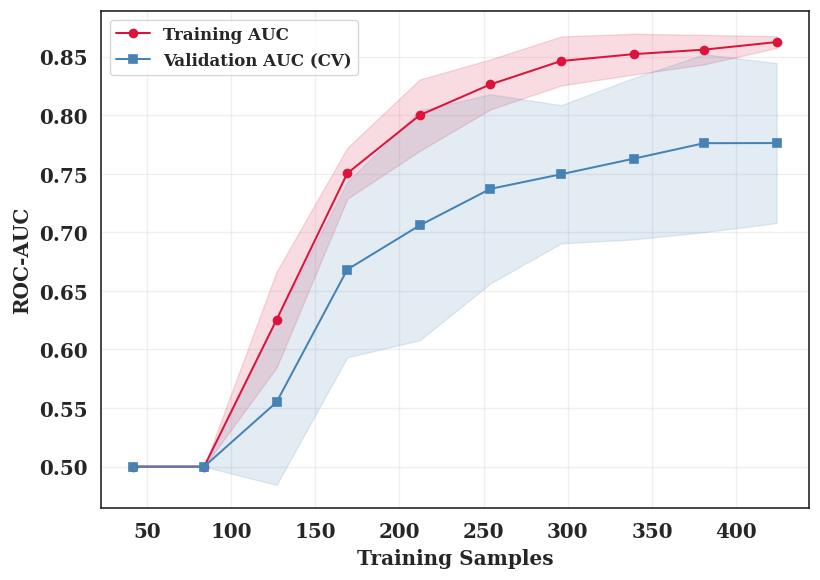


FINAL SUMMARY — LightGBM Reportable Results
Best Params  : {'n_estimators': np.int64(543), 'learning_rate': 0.2346691807436847, 'num_leaves': np.int64(111), 'min_child_samples': np.int64(47), 'subsample': 0.5433270753463759, 'colsample_bytree': 0.9576014450486008, 'reg_alpha': 0.9971866560765537, 'reg_lambda': 0.9223939072661962}

Single Split Results (train/test = 80/20):
  Train AUC       : 0.8691
  Test  AUC       : 0.6892
  Bootstrap 95% CI: [0.5808 – 0.7879]

10-Fold CV Results (primary reportable):
  AUC       : 0.7775 ± 0.0668
  Accuracy  : 0.7141 ± 0.0500
  F1        : 0.7064 ± 0.0630
  Precision : 0.7421 ± 0.0605
  Recall    : 0.6847 ± 0.1039

Saved figures:
  lgbm_confusion_matrix.png
  lgbm_roc_curve.png
  lgbm_learning_curve.png


In [23]:
# ==============================================================
# IMPORTS
# ==============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_validate, learning_curve)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     f1_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.utils           import resample

warnings.filterwarnings('ignore')

# ==============================================================
# SECTION 0 — Bayesian Optimisation
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — LightGBM (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

lgbm_space = [
    Integer(50,  600,  name='n_estimators'),
    Real(0.01,   0.3,  prior='log-uniform', name='learning_rate'),
    Integer(15,  127,  name='num_leaves'),
    Integer(5,   50,   name='min_child_samples'),
    Real(0.5,    1.0,  name='subsample'),
    Real(0.5,    1.0,  name='colsample_bytree'),
    Real(0.0,    1.0,  name='reg_alpha'),
    Real(0.0,    2.0,  name='reg_lambda'),
]

# ✓ all types explicitly cast — fixes sklearn clone error
def build_lgbm(n_estimators, learning_rate, num_leaves,
               min_child_samples, subsample, colsample_bytree,
               reg_alpha, reg_lambda):
    return lgb.LGBMClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        num_leaves=int(num_leaves),
        min_child_samples=int(min_child_samples),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        reg_alpha=float(reg_alpha),
        reg_lambda=float(reg_lambda),
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )

lgbm_best, lgbm_cv_auc = run_bayes_opt(lgbm_space, build_lgbm, n_calls=80)
print(f'Best CV AUC : {lgbm_cv_auc:.4f}')
print(f'Best params : {lgbm_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
lgbm_final = build_lgbm(**lgbm_best)
lgbm_final.fit(X_train_sc, y_train)
lgbm_model = fit_and_evaluate('LightGBM', lgbm_final, lgbm_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — LightGBM')
print('=' * 60)

seed_results_lgbm = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    seed_model = build_lgbm(**lgbm_best)
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results_lgbm.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df_lgbm = pd.DataFrame(seed_results_lgbm)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df_lgbm['test_auc'].mean():.4f} "
      f"± {seed_df_lgbm['test_auc'].std():.4f}  "
      f"[min={seed_df_lgbm['test_auc'].min():.4f}, "
      f"max={seed_df_lgbm['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df_lgbm['test_acc'].mean():.4f} "
      f"± {seed_df_lgbm['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df_lgbm['test_f1'].mean():.4f} "
      f"± {seed_df_lgbm['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df_lgbm['gap'].mean():.4f} "
      f"± {seed_df_lgbm['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — LightGBM (reportable result)')
print('=' * 60)

lgbm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMClassifier(
        n_estimators=int(lgbm_best['n_estimators']),
        learning_rate=float(lgbm_best['learning_rate']),
        num_leaves=int(lgbm_best['num_leaves']),
        min_child_samples=int(lgbm_best['min_child_samples']),
        subsample=float(lgbm_best['subsample']),
        colsample_bytree=float(lgbm_best['colsample_bytree']),
        reg_alpha=float(lgbm_best['reg_alpha']),
        reg_lambda=float(lgbm_best['reg_lambda']),
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

cv_report_lgbm = cross_validate(
    lgbm_pipe, X, y,
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
for label, key in cv_metrics.items():
    tr  = cv_report_lgbm[f'train_{key}'].mean()
    te  = cv_report_lgbm[f'test_{key}'].mean()
    std = cv_report_lgbm[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te = cv_report_lgbm[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% CI on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs = []
    rng  = np.random.RandomState(seed)
    y_te = np.array(y_te)
    for _ in range(n_bootstrap):
        idx     = resample(range(len(y_te)), random_state=rng)
        y_bs    = y_te[idx]
        prob_bs = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

lgbm_mean_auc, lgbm_lower, lgbm_upper = bootstrap_auc_ci(
    lgbm_final, X_test_sc, y_test
)
print(f"LightGBM AUC : {lgbm_mean_auc:.4f}  "
      f"(95% CI: {lgbm_lower:.4f} – {lgbm_upper:.4f})")

# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — LightGBM')
print('=' * 60)

y_pred_lgbm = lgbm_final.predict(X_test_sc)
cm_lgbm     = confusion_matrix(y_test, y_pred_lgbm)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='YlOrRd')
ax.set_title('',
             fontsize=11)
plt.tight_layout()
plt.savefig('lgbm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:\n{cm_lgbm}")
print(f"\nTN={cm_lgbm[0,0]}  FP={cm_lgbm[0,1]}")
print(f"FN={cm_lgbm[1,0]}  TP={cm_lgbm[1,1]}")

# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — LightGBM with 95% CI Band')
print('=' * 60)

y_prob_lgbm           = lgbm_final.predict_proba(X_test_sc)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
roc_auc_lgbm           = auc(fpr_lgbm, tpr_lgbm)

tprs_boot_lgbm = []
base_fpr       = np.linspace(0, 1, 100)
rng            = np.random.RandomState(SEED)
y_test_arr     = np.array(y_test)

for _ in range(1000):
    idx     = resample(range(len(y_test_arr)), random_state=rng)
    y_bs    = y_test_arr[idx]
    prob_bs = y_prob_lgbm[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot_lgbm.append(tpr_interp)

tprs_boot_lgbm = np.array(tprs_boot_lgbm)
lower_tpr_lgbm = np.percentile(tprs_boot_lgbm, 2.5,  axis=0)
upper_tpr_lgbm = np.percentile(tprs_boot_lgbm, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lgbm, tpr_lgbm, color='crimson', lw=2,
        label=f'LightGBM ROC (AUC = {roc_auc_lgbm:.4f})')
ax.fill_between(base_fpr, lower_tpr_lgbm, upper_tpr_lgbm,
                alpha=0.2, color='crimson',
                label=f'95% CI [{lgbm_lower:.4f} – {lgbm_upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lgbm_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 7 — Learning Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — LightGBM')
print('=' * 60)

train_sizes, train_scores_lgbm, val_scores_lgbm = learning_curve(
    lgbm_pipe, X, y,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=SEED
)

train_mean_lgbm = train_scores_lgbm.mean(axis=1)
train_std_lgbm  = train_scores_lgbm.std(axis=1)
val_mean_lgbm   = val_scores_lgbm.mean(axis=1)
val_std_lgbm    = val_scores_lgbm.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean_lgbm, 'o-', color='crimson',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean_lgbm - train_std_lgbm,
                train_mean_lgbm + train_std_lgbm,
                alpha=0.15, color='crimson')
ax.plot(train_sizes, val_mean_lgbm, 's-', color='steelblue',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean_lgbm - val_std_lgbm,
                val_mean_lgbm + val_std_lgbm,
                alpha=0.15, color='steelblue')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lgbm_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — LightGBM Reportable Results')
print('=' * 60)
print(f"Best Params  : {lgbm_best}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : "
      f"{roc_auc_score(y_train, lgbm_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : "
      f"{roc_auc_score(y_test,  lgbm_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{lgbm_lower:.4f} – {lgbm_upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report_lgbm[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  lgbm_confusion_matrix.png")
print(f"  lgbm_roc_curve.png")
print(f"  lgbm_learning_curve.png")

## Section 11 — AdaBoost

Bayesian Optimisation — AdaBoost (80 calls)
Best CV AUC : 0.7950
Best params : {'n_estimators': np.int64(176), 'learning_rate': 0.6229860423635283, 'max_depth': np.int64(2)}

--- AdaBoost — train ---
  Accuracy  : 0.8143
  ROC-AUC   : 0.9082
  F1        : 0.8168
  Precision : 0.8211
  Recall    : 0.8125
  Brier     : 0.1974
              precision    recall  f1-score   support

    Not Ctrl       0.81      0.82      0.81       185
        Ctrl       0.82      0.81      0.82       192

    accuracy                           0.81       377
   macro avg       0.81      0.81      0.81       377
weighted avg       0.81      0.81      0.81       377


--- AdaBoost — test ---
  Accuracy  : 0.6632
  ROC-AUC   : 0.6886
  F1        : 0.6522
  Precision : 0.6977
  Recall    : 0.6122
  Brier     : 0.2304
              precision    recall  f1-score   support

    Not Ctrl       0.63      0.72      0.67        46
        Ctrl       0.70      0.61      0.65        49

    accuracy                    

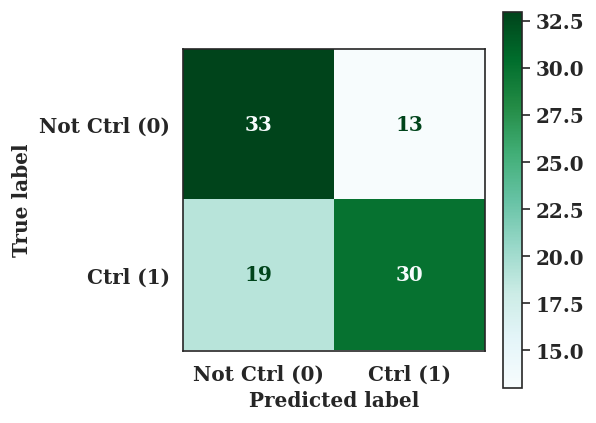


Confusion Matrix:
[[33 13]
 [19 30]]

TN=33  FP=13
FN=19  TP=30

ROC Curve — AdaBoost with 95% CI Band


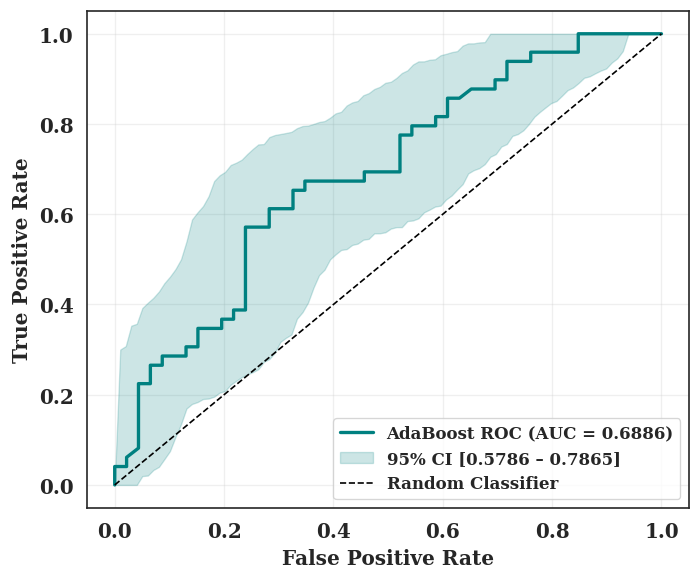


Learning Curve — AdaBoost


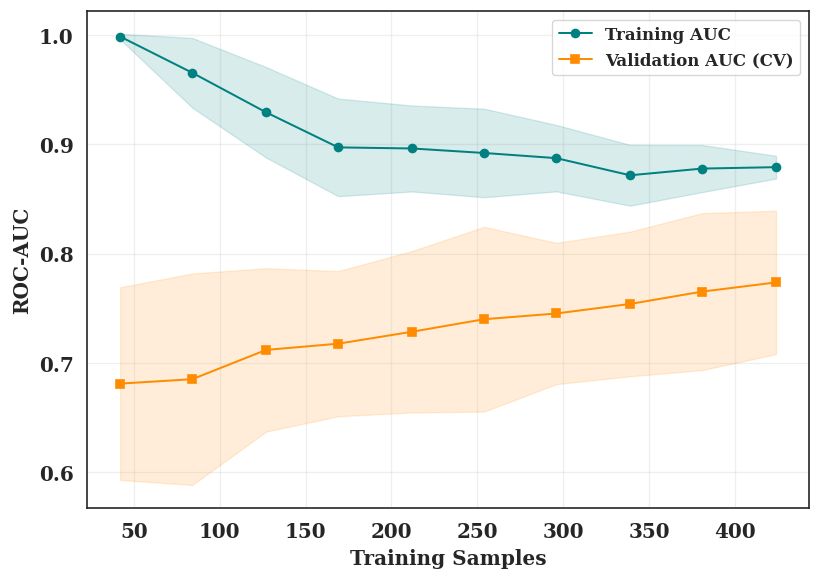


FINAL SUMMARY — AdaBoost Reportable Results
Best Params  : {'n_estimators': np.int64(176), 'learning_rate': 0.6229860423635283, 'max_depth': np.int64(2)}

Single Split Results (train/test = 80/20):
  Train AUC       : 0.9082
  Test  AUC       : 0.6886
  Bootstrap 95% CI: [0.5786 – 0.7865]

10-Fold CV Results (primary reportable):
  AUC       : 0.7632 ± 0.0712
  Accuracy  : 0.6843 ± 0.0777
  F1        : 0.6880 ± 0.0927
  Precision : 0.6862 ± 0.0666
  Recall    : 0.6968 ± 0.1283

Saved figures:
  ada_confusion_matrix.png
  ada_roc_curve.png
  ada_learning_curve.png


In [24]:
# ==============================================================
# IMPORTS
# ==============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble        import AdaBoostClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_validate, learning_curve)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     f1_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve, auc)
from sklearn.utils           import resample

warnings.filterwarnings('ignore')

# ==============================================================
# SECTION 0 — Bayesian Optimisation
# ==============================================================
print('=' * 60)
print('Bayesian Optimisation — AdaBoost (80 calls)')
print('=' * 60)

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

ada_space = [
    Integer(50,  500, name='n_estimators'),
    Real(0.01,   2.0, prior='log-uniform', name='learning_rate'),
    Integer(1,   5,   name='max_depth'),
]

# ✓ all types explicitly cast — fixes sklearn clone error
def build_ada(n_estimators, learning_rate, max_depth):
    base = DecisionTreeClassifier(
        max_depth=int(max_depth),
        random_state=SEED
    )
    return AdaBoostClassifier(
        estimator=base,
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        random_state=SEED
    )

ada_best, ada_cv_auc = run_bayes_opt(ada_space, build_ada, n_calls=80)
print(f'Best CV AUC : {ada_cv_auc:.4f}')
print(f'Best params : {ada_best}')

# ==============================================================
# SECTION 1 — Final Model
# ==============================================================
ada_final = build_ada(**ada_best)
ada_final.fit(X_train_sc, y_train)
ada_model = fit_and_evaluate('AdaBoost', ada_final, ada_cv_auc)

# ==============================================================
# SECTION 2 — Seed Variance Test
# ==============================================================
print()
print('=' * 60)
print('Seed Variance Test — AdaBoost')
print('=' * 60)

seed_results_ada = []

for seed in [42, 0, 7, 123, 999]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    seed_model = build_ada(**ada_best)
    seed_model.fit(X_tr_sc, y_tr)

    train_auc = roc_auc_score(y_tr, seed_model.predict_proba(X_tr_sc)[:, 1])
    test_auc  = roc_auc_score(y_te, seed_model.predict_proba(X_te_sc)[:, 1])
    test_acc  = accuracy_score(y_te, seed_model.predict(X_te_sc))
    test_f1   = f1_score(y_te, seed_model.predict(X_te_sc))

    seed_results_ada.append({
        'seed'     : seed,
        'train_auc': train_auc,
        'test_auc' : test_auc,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'gap'      : train_auc - test_auc
    })

    print(f'Seed {seed:>4} | Train AUC: {train_auc:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Acc: {test_acc:.4f} | '
          f'F1: {test_f1:.4f} | '
          f'Gap: {train_auc - test_auc:.4f}')

seed_df_ada = pd.DataFrame(seed_results_ada)
print()
print('--- Seed Variance Summary ---')
print(f"Test AUC  : {seed_df_ada['test_auc'].mean():.4f} "
      f"± {seed_df_ada['test_auc'].std():.4f}  "
      f"[min={seed_df_ada['test_auc'].min():.4f}, "
      f"max={seed_df_ada['test_auc'].max():.4f}]")
print(f"Test Acc  : {seed_df_ada['test_acc'].mean():.4f} "
      f"± {seed_df_ada['test_acc'].std():.4f}")
print(f"Test F1   : {seed_df_ada['test_f1'].mean():.4f} "
      f"± {seed_df_ada['test_f1'].std():.4f}")
print(f"Train-Test Gap : {seed_df_ada['gap'].mean():.4f} "
      f"± {seed_df_ada['gap'].std():.4f}")

# ==============================================================
# SECTION 3 — 10-Fold CV (reportable result)
# ==============================================================
print()
print('=' * 60)
print('10-Fold Stratified CV — AdaBoost (reportable result)')
print('=' * 60)

ada_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ada', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=int(ada_best['max_depth']),
            random_state=SEED
        ),
        n_estimators=int(ada_best['n_estimators']),
        learning_rate=float(ada_best['learning_rate']),
        random_state=SEED
    ))
])

cv_report_ada = cross_validate(
    ada_pipe, X, y,
    cv=CV,
    scoring={
        'auc'      : 'roc_auc',
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

cv_metrics = {
    'AUC'      : 'auc',
    'Accuracy' : 'accuracy',
    'F1'       : 'f1',
    'Precision': 'precision',
    'Recall'   : 'recall',
}

print(f"{'Metric':<12} {'Train':>10} {'Test':>10} {'Std':>8}")
print('-' * 44)
for label, key in cv_metrics.items():
    tr  = cv_report_ada[f'train_{key}'].mean()
    te  = cv_report_ada[f'test_{key}'].mean()
    std = cv_report_ada[f'test_{key}'].std()
    print(f"{label:<12} {tr:>10.4f} {te:>10.4f} {std:>8.4f}")

print()
print('--- Reportable results for paper ---')
for label, key in cv_metrics.items():
    te = cv_report_ada[f'test_{key}']
    print(f"CV {label:<10}: {te.mean():.4f} ± {te.std():.4f} "
          f"[{te.min():.4f} – {te.max():.4f}]")

# ==============================================================
# SECTION 4 — Bootstrap 95% CI on AUC
# ==============================================================
print()
print('=' * 60)
print('Bootstrap 95% CI — AUC (1000 iterations)')
print('=' * 60)

def bootstrap_auc_ci(model, X_te, y_te, n_bootstrap=1000, seed=42):
    aucs = []
    rng  = np.random.RandomState(seed)
    y_te = np.array(y_te)
    for _ in range(n_bootstrap):
        idx     = resample(range(len(y_te)), random_state=rng)
        y_bs    = y_te[idx]
        prob_bs = model.predict_proba(X_te[idx])[:, 1]
        if len(np.unique(y_bs)) < 2:
            continue
        aucs.append(roc_auc_score(y_bs, prob_bs))
    mean  = np.mean(aucs)
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return mean, lower, upper

ada_mean_auc, ada_lower, ada_upper = bootstrap_auc_ci(
    ada_final, X_test_sc, y_test
)
print(f"AdaBoost AUC : {ada_mean_auc:.4f}  "
      f"(95% CI: {ada_lower:.4f} – {ada_upper:.4f})")

# ==============================================================
# SECTION 5 — Confusion Matrix
# ==============================================================
print()
print('=' * 60)
print('Confusion Matrix — AdaBoost')
print('=' * 60)

y_pred_ada = ada_final.predict(X_test_sc)
cm_ada     = confusion_matrix(y_test, y_pred_ada)

fig, ax = plt.subplots(figsize=(5, 4))
disp    = ConfusionMatrixDisplay(
    confusion_matrix=cm_ada,
    display_labels=['Not Ctrl (0)', 'Ctrl (1)']
)
disp.plot(ax=ax, colorbar=True, cmap='BuGn')
ax.set_title('',
             fontsize=11)
plt.tight_layout()
plt.savefig('ada_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix:\n{cm_ada}")
print(f"\nTN={cm_ada[0,0]}  FP={cm_ada[0,1]}")
print(f"FN={cm_ada[1,0]}  TP={cm_ada[1,1]}")

# ==============================================================
# SECTION 6 — ROC Curve with 95% CI Band
# ==============================================================
print()
print('=' * 60)
print('ROC Curve — AdaBoost with 95% CI Band')
print('=' * 60)

y_prob_ada          = ada_final.predict_proba(X_test_sc)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
roc_auc_ada          = auc(fpr_ada, tpr_ada)

tprs_boot_ada = []
base_fpr      = np.linspace(0, 1, 100)
rng           = np.random.RandomState(SEED)
y_test_arr    = np.array(y_test)

for _ in range(1000):
    idx     = resample(range(len(y_test_arr)), random_state=rng)
    y_bs    = y_test_arr[idx]
    prob_bs = y_prob_ada[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_bs, prob_bs)
    tpr_interp       = np.interp(base_fpr, fpr_b, tpr_b)
    tpr_interp[0]    = 0.0
    tprs_boot_ada.append(tpr_interp)

tprs_boot_ada = np.array(tprs_boot_ada)
lower_tpr_ada = np.percentile(tprs_boot_ada, 2.5,  axis=0)
upper_tpr_ada = np.percentile(tprs_boot_ada, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_ada, tpr_ada, color='teal', lw=2,
        label=f'AdaBoost ROC (AUC = {roc_auc_ada:.4f})')
ax.fill_between(base_fpr, lower_tpr_ada, upper_tpr_ada,
                alpha=0.2, color='teal',
                label=f'95% CI [{ada_lower:.4f} – {ada_upper:.4f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ada_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 7 — Learning Curve
# ==============================================================
print()
print('=' * 60)
print('Learning Curve — AdaBoost')
print('=' * 60)

train_sizes, train_scores_ada, val_scores_ada = learning_curve(
    ada_pipe, X, y,
    cv=CV,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=SEED
)

train_mean_ada = train_scores_ada.mean(axis=1)
train_std_ada  = train_scores_ada.std(axis=1)
val_mean_ada   = val_scores_ada.mean(axis=1)
val_std_ada    = val_scores_ada.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean_ada, 'o-', color='teal',
        label='Training AUC')
ax.fill_between(train_sizes,
                train_mean_ada - train_std_ada,
                train_mean_ada + train_std_ada,
                alpha=0.15, color='teal')
ax.plot(train_sizes, val_mean_ada, 's-', color='darkorange',
        label='Validation AUC (CV)')
ax.fill_between(train_sizes,
                val_mean_ada - val_std_ada,
                val_mean_ada + val_std_ada,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Training Samples', fontsize=12)
ax.set_ylabel('ROC-AUC',          fontsize=12)
ax.set_title('', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ada_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# SECTION 8 — Final Summary
# ==============================================================
print()
print('=' * 60)
print('FINAL SUMMARY — AdaBoost Reportable Results')
print('=' * 60)
print(f"Best Params  : {ada_best}")
print()
print(f"Single Split Results (train/test = 80/20):")
print(f"  Train AUC       : "
      f"{roc_auc_score(y_train, ada_final.predict_proba(X_train_sc)[:,1]):.4f}")
print(f"  Test  AUC       : "
      f"{roc_auc_score(y_test,  ada_final.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"  Bootstrap 95% CI: [{ada_lower:.4f} – {ada_upper:.4f}]")
print()
print(f"10-Fold CV Results (primary reportable):")
for label, key in cv_metrics.items():
    te = cv_report_ada[f'test_{key}']
    print(f"  {label:<10}: {te.mean():.4f} ± {te.std():.4f}")
print()
print(f"Saved figures:")
print(f"  ada_confusion_matrix.png")
print(f"  ada_roc_curve.png")
print(f"  ada_learning_curve.png")

## Calibration plot

Calibration Results (Brier Score)
MLP              Brier score: 0.2605
Random Forest    Brier score: 0.2087
XGBoost          Brier score: 0.2427
LightGBM         Brier score: 0.2380
CatBoost         Brier score: 0.2305
AdaBoost         Brier score: 0.2304


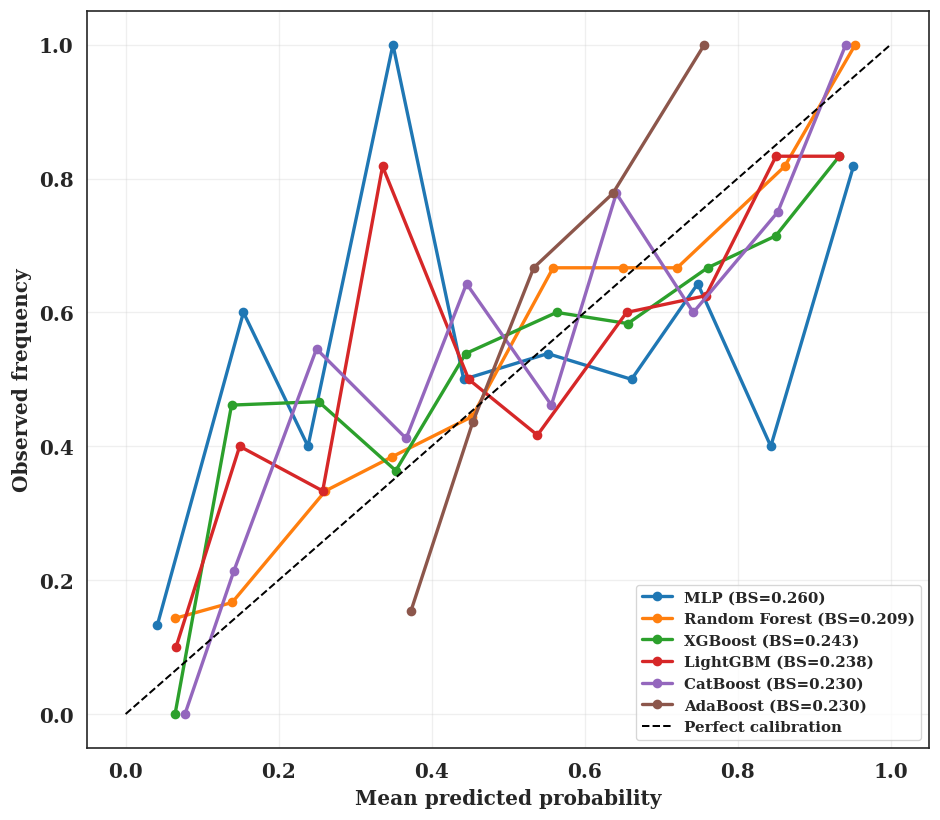


Saved: calibration_plot.png


In [30]:
# ==============================================================
# Calibration Plot (Reliability Diagram)
# ==============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 7))

print('=' * 60)
print("Calibration Results (Brier Score)")
print('=' * 60)

for name, model in models_dict.items():
    prob_pos = model.predict_proba(X_test_sc)[:, 1]

    frac_pos, mean_pred = calibration_curve(
        y_test_arr,
        prob_pos,
        n_bins=10,
        strategy='uniform'
    )

    brier = brier_score_loss(y_test_arr, prob_pos)

    print(f"{name:<16} Brier score: {brier:.4f}")

    plt.plot(
        mean_pred,
        frac_pos,
        marker='o',
        linewidth=2,
        label=f'{name} (BS={brier:.3f})'
    )

# Perfect calibration line
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='black',
         label='Perfect calibration')

plt.xlabel('Mean predicted probability', fontsize=12)
plt.ylabel('Observed frequency', fontsize=12)
plt.title('', fontsize=14)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Saved: calibration_plot.png')

McNemar's Test — Pairwise Model Comparison
Model              Accuracy        AUC
----------------------------------------
MLP                  0.6000     0.6597
Random Forest        0.6947     0.7347
XGBoost              0.6105     0.6713
LightGBM             0.5895     0.6892
CatBoost             0.6000     0.6943
AdaBoost             0.6632     0.6886

Pairwise McNemar's Test Results
Model 1          Model 2             b    c    p-value          Sig
--------------------------------------------------------------------
MLP              Random Forest       4   13     0.0490   *   p<0.05
MLP              XGBoost             8    9     1.0000           ns
MLP              LightGBM            9    8     1.0000           ns
MLP              CatBoost           10   10     1.0000           ns
MLP              AdaBoost            6   12     0.2379           ns
Random Forest    XGBoost            15    7     0.1338           ns
Random Forest    LightGBM           15    5     0.0414   *   p<0.

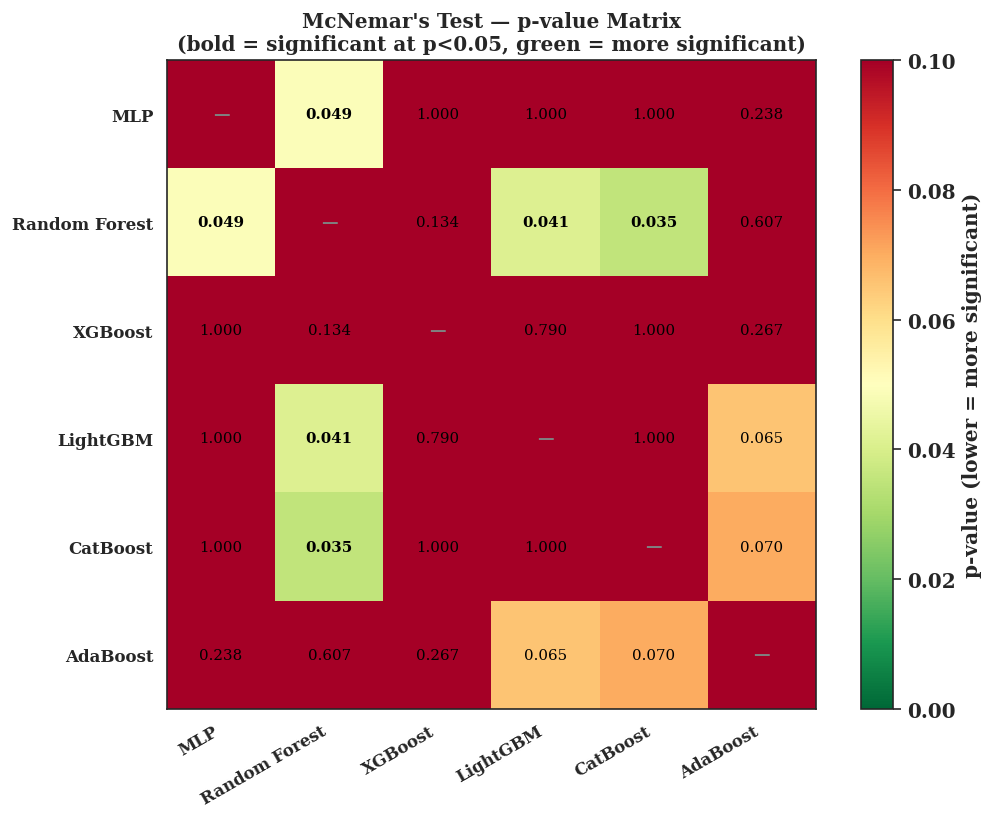


Saved: mcnemar_heatmap.png
Saved: mcnemar_results.csv

--- Note for paper ---
McNemar's test evaluates whether two classifiers make
significantly different errors on the same test set.
Exact binomial test used when b+c < 25.
Chi-squared approximation used when b+c >= 25.
Significance threshold: α = 0.05


In [26]:
# ==============================================================
# McNemar's Test — All Model Pairwise Comparison
# ==============================================================
print('=' * 60)
print("McNemar's Test — Pairwise Model Comparison")
print('=' * 60)

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# --------------------------------------------------------------
# সব model এর predictions collect করুন
# --------------------------------------------------------------
models_dict = {
    'MLP'          : mlp_final,
    'Random Forest': rf_final,
    'XGBoost'      : xgb_final,
    'LightGBM'     : lgbm_final,
    'CatBoost'     : cb_final,
    'AdaBoost'     : ada_final,
}

y_test_arr = np.array(y_test)

predictions = {}
print(f"{'Model':<16} {'Accuracy':>10} {'AUC':>10}")
print('-' * 40)
for name, model in models_dict.items():
    pred              = model.predict(X_test_sc)
    predictions[name] = pred
    acc = accuracy_score(y_test_arr, pred)
    auc_val = roc_auc_score(
        y_test_arr,
        model.predict_proba(X_test_sc)[:, 1]
    )
    print(f"{name:<16} {acc:>10.4f} {auc_val:>10.4f}")

# --------------------------------------------------------------
# Pairwise McNemar's Test
# --------------------------------------------------------------
print()
print('=' * 60)
print("Pairwise McNemar's Test Results")
print('=' * 60)
print(f"{'Model 1':<16} {'Model 2':<16} {'b':>4} {'c':>4} "
      f"{'p-value':>10} {'Sig':>12}")
print('-' * 68)

model_names     = list(models_dict.keys())
mcnemar_results = []

for name1, name2 in combinations(model_names, 2):
    pred1    = predictions[name1]
    pred2    = predictions[name2]

    correct1 = (pred1 == y_test_arr)
    correct2 = (pred2 == y_test_arr)

    b = int(np.sum( correct1 & ~correct2))  # model1 correct, model2 wrong
    c = int(np.sum(~correct1 &  correct2))  # model1 wrong, model2 correct

    exact  = (b + c) < 25                   # exact test for small n
    table  = [[0, b], [c, 0]]
    result = mcnemar(table, exact=exact)
    p      = result.pvalue

    if p < 0.001:
        sig = '*** p<0.001'
    elif p < 0.01:
        sig = '**  p<0.01'
    elif p < 0.05:
        sig = '*   p<0.05'
    else:
        sig = 'ns'

    print(f"{name1:<16} {name2:<16} {b:>4} {c:>4} "
          f"{p:>10.4f} {sig:>12}")

    mcnemar_results.append({
        'Model 1' : name1,
        'Model 2' : name2,
        'b'       : b,
        'c'       : c,
        'p-value' : round(p, 4),
        'Sig'     : sig,
        'exact'   : exact
    })

mcnemar_df = pd.DataFrame(mcnemar_results)

# --------------------------------------------------------------
# Summary
# --------------------------------------------------------------
print()
print('=' * 60)
print('Summary')
print('=' * 60)

sig_pairs = mcnemar_df[mcnemar_df['p-value'] < 0.05]
ns_pairs  = mcnemar_df[mcnemar_df['p-value'] >= 0.05]

print(f"\nSignificantly different pairs (p<0.05): {len(sig_pairs)}")
for _, row in sig_pairs.iterrows():
    print(f"  ✓ {row['Model 1']} vs {row['Model 2']} "
          f"(p={row['p-value']:.4f}) {row['Sig']}")

print(f"\nNot significantly different (p≥0.05): {len(ns_pairs)}")
for _, row in ns_pairs.iterrows():
    print(f"  ✗ {row['Model 1']} vs {row['Model 2']} "
          f"(p={row['p-value']:.4f})")

# --------------------------------------------------------------
# MLP vs all baselines — focused
# --------------------------------------------------------------
print()
print('=' * 60)
print('MLP (Proposed) vs All Baselines')
print('=' * 60)
print(f"{'Comparison':<35} {'b':>4} {'c':>4} "
      f"{'p-value':>10} {'Result':>20}")
print('-' * 76)

for name in model_names:
    if name == 'MLP':
        continue
    row = mcnemar_df[
        ((mcnemar_df['Model 1'] == 'MLP') &
         (mcnemar_df['Model 2'] == name)) |
        ((mcnemar_df['Model 1'] == name) &
         (mcnemar_df['Model 2'] == 'MLP'))
    ].iloc[0]

    result = ('Sig. different *'
              if row['p-value'] < 0.05
              else 'Not significant')
    print(f"{'MLP vs ' + name:<35} {row['b']:>4} {row['c']:>4} "
          f"{row['p-value']:>10.4f} {result:>20}")

# --------------------------------------------------------------
# Heatmap
# --------------------------------------------------------------
print()
print('=' * 60)
print("McNemar's Test p-value Heatmap")
print('=' * 60)

n           = len(model_names)
pval_matrix = np.ones((n, n))

for _, row in mcnemar_df.iterrows():
    i = model_names.index(row['Model 1'])
    j = model_names.index(row['Model 2'])
    pval_matrix[i, j] = row['p-value']
    pval_matrix[j, i] = row['p-value']

fig, ax = plt.subplots(figsize=(9, 7))
im      = ax.imshow(pval_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)

for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=10, color='gray')
        else:
            p    = pval_matrix[i, j]
            text = f'{p:.3f}'
            fw   = 'bold' if p < 0.05 else 'normal'
            col  = 'white' if p < 0.02 else 'black'
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=9, color=col, fontweight=fw)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(model_names, fontsize=10)
ax.set_title(
    "McNemar's Test — p-value Matrix\n"
    "(bold = significant at p<0.05, green = more significant)",
    fontsize=12
)
plt.colorbar(im, ax=ax, label='p-value (lower = more significant)')
plt.tight_layout()
plt.savefig('mcnemar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------------------
# Export to CSV
# --------------------------------------------------------------
mcnemar_df.to_csv('mcnemar_results.csv', index=False)
print()
print('Saved: mcnemar_heatmap.png')
print('Saved: mcnemar_results.csv')
print()
print('--- Note for paper ---')
print("McNemar's test evaluates whether two classifiers make")
print("significantly different errors on the same test set.")
print("Exact binomial test used when b+c < 25.")
print("Chi-squared approximation used when b+c >= 25.")
print("Significance threshold: α = 0.05")

## Section 13 — SHAP Explainability (All Models)

| Model type | SHAP Explainer used |
|---|---|
| Random Forest, XGBoost, LightGBM, CatBoost, AdaBoost | `TreeExplainer` (exact, fast) |
| MLP (sklearn) | `KernelExplainer` (model-agnostic, slower) |
| ANN (Keras) | `DeepExplainer` → fallback `GradientExplainer` |

Plots generated per model: **Beeswarm**, **Bar (mean |SHAP|)**, **Waterfall**, **Force**  
Additional for tree models: **Dependence plots**, **SHAP Heatmap**  
Final: **Cross-model consensus feature importance**

In [31]:
print(type(X))
print(X.shape)

# যদি pandas হয়
if hasattr(X, 'columns'):
    print(X.columns.tolist())
else:
    print("numpy array — column names নেই")

<class 'numpy.ndarray'>
(472, 13)
numpy array — column names নেই


In [32]:
# আপনার original dataframe এর column names দেখুন
print(data.columns.tolist())

['HosLevel', 'Socio Economic Status', 'BMI', 'PolyPharmacy', 'MS_Control', 'Comorbidity', 'Dietary Patterns', 'Physical Activity', 'Medication Adharance', 'Community Participation', 'Clinic Service', 'Screening', 'Health behavior monitoring', 'Communities Outreach']


In [33]:
# --------------------------------------------------------------
# TreeExplainer — best for Random Forest
# --------------------------------------------------------------
print()
print('=' * 60)
print('SHAP — TreeExplainer (Random Forest)')
print('=' * 60)

explainer_rf   = shap.TreeExplainer(rf_final)
shap_values_rf = explainer_rf.shap_values(X_test)

# Debug — দেখুন কী আসছে
print(f'Type of shap_values   : {type(shap_values_rf)}')
print(f'Type of expected_value: {type(explainer_rf.expected_value)}')
print(f'Expected value        : {explainer_rf.expected_value}')

# --------------------------------------------------------------
# ✓ Fix — expected_value handle করুন
# --------------------------------------------------------------
if isinstance(shap_values_rf, list):
    sv       = shap_values_rf[1]           # class 1
    ev       = explainer_rf.expected_value
    base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)
elif len(shap_values_rf.shape) == 3:
    sv       = shap_values_rf[:, :, 1]     # shape (n, features, classes)
    ev       = explainer_rf.expected_value
    base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)
else:
    sv       = shap_values_rf
    ev       = explainer_rf.expected_value
    base_val = float(ev[0]) if hasattr(ev, '__len__') else float(ev)

print(f'SHAP values shape : {sv.shape}')
print(f'Base value        : {base_val:.4f}')


SHAP — TreeExplainer (Random Forest)
Type of shap_values   : <class 'numpy.ndarray'>
Type of expected_value: <class 'numpy.ndarray'>
Expected value        : [0.50137514 0.49862486]
SHAP values shape : (95, 13)
Base value        : 0.4986



--- Plot 1: Beeswarm Summary ---


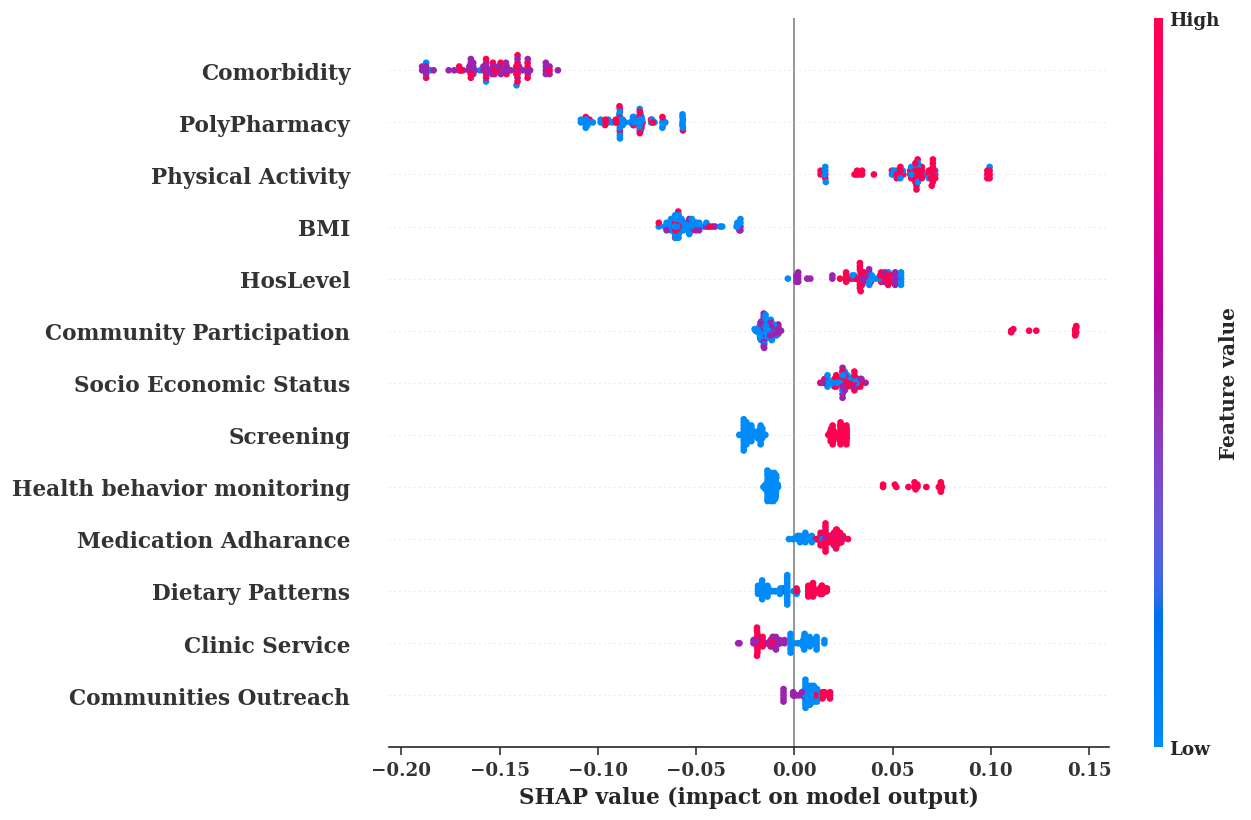

Saved: rf_shap_beeswarm.png


In [34]:
# ==============================================================
# Plot 1 — Beeswarm Summary Plot
# ==============================================================
print('\n--- Plot 1: Beeswarm Summary ---')
plt.figure(figsize=(11, 7))
shap.summary_plot(
    sv,
    X_test,
    feature_names=FEATURE_NAMES,
    show=False,
    plot_size=None
)
plt.title('',
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('rf_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: rf_shap_beeswarm.png')


--- Plot 2: Feature Importance Bar (Mean |SHAP|) ---


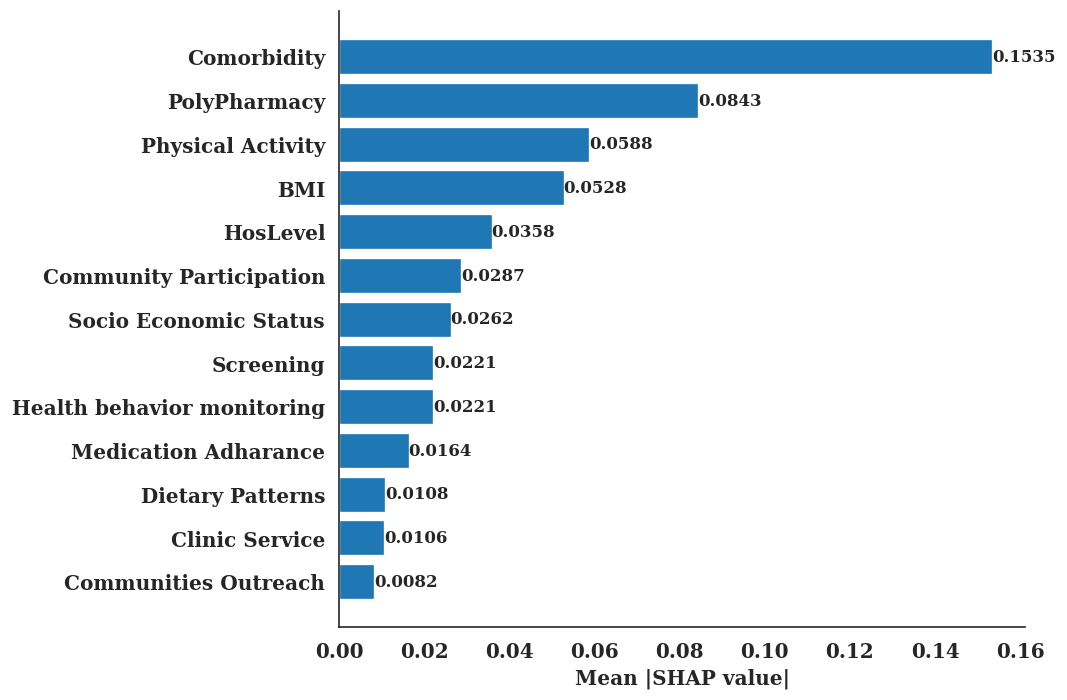

Saved: rf_shap_bar.png


In [37]:
# ==============================================================
# Bar Plot — Mean |SHAP| with Data Labels
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt

print('\n--- Plot 2: Feature Importance Bar (Mean |SHAP|) ---')

# Compute mean absolute SHAP values
mean_shap = np.abs(sv).mean(axis=0)

# Sort features by importance
sorted_idx = np.argsort(mean_shap)
mean_shap_sorted = mean_shap[sorted_idx]
features_sorted = np.array(FEATURE_NAMES)[sorted_idx]

# Plot
plt.figure(figsize=(9, 6))
bars = plt.barh(features_sorted, mean_shap_sorted)
ax = plt.gca()   # get current axis

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# X-axis label
plt.xlabel('Mean |SHAP value|', fontsize=12)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('rf_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: rf_shap_bar.png')


--- Plot 3: Waterfall (Instance 0) ---


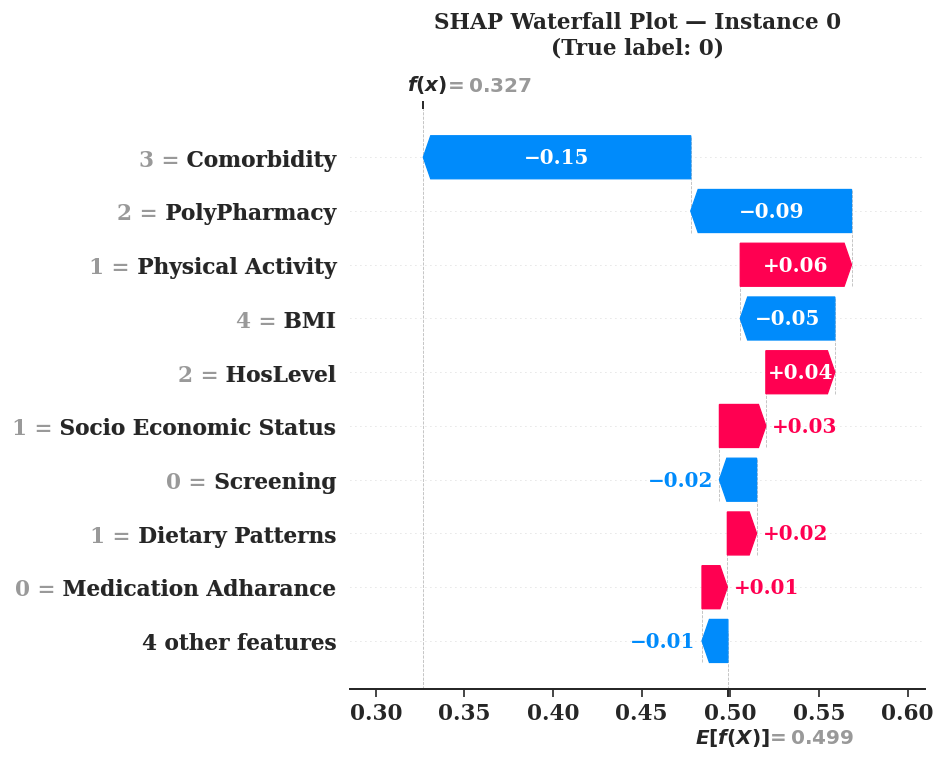

Saved: rf_shap_waterfall.png


In [38]:
# ==============================================================
# Plot 3 — Waterfall Plot
# ==============================================================
INSTANCE_IDX = 0
print(f'\n--- Plot 3: Waterfall (Instance {INSTANCE_IDX}) ---')

explanation = shap.Explanation(
    values        = sv[INSTANCE_IDX],
    base_values   = base_val,
    data          = X_test[INSTANCE_IDX],   # ✅ FIX HERE
    feature_names = FEATURE_NAMES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)

plt.title(
    f'SHAP Waterfall Plot — Instance {INSTANCE_IDX}\n'
    f'(True label: {int(np.array(y_test)[INSTANCE_IDX])})',
    fontsize=13,
    pad=12
)

plt.tight_layout()
plt.savefig('rf_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: rf_shap_waterfall.png')


--- Plot 4: Force Plot (Instance 0) ---


<Figure size 1680x360 with 0 Axes>

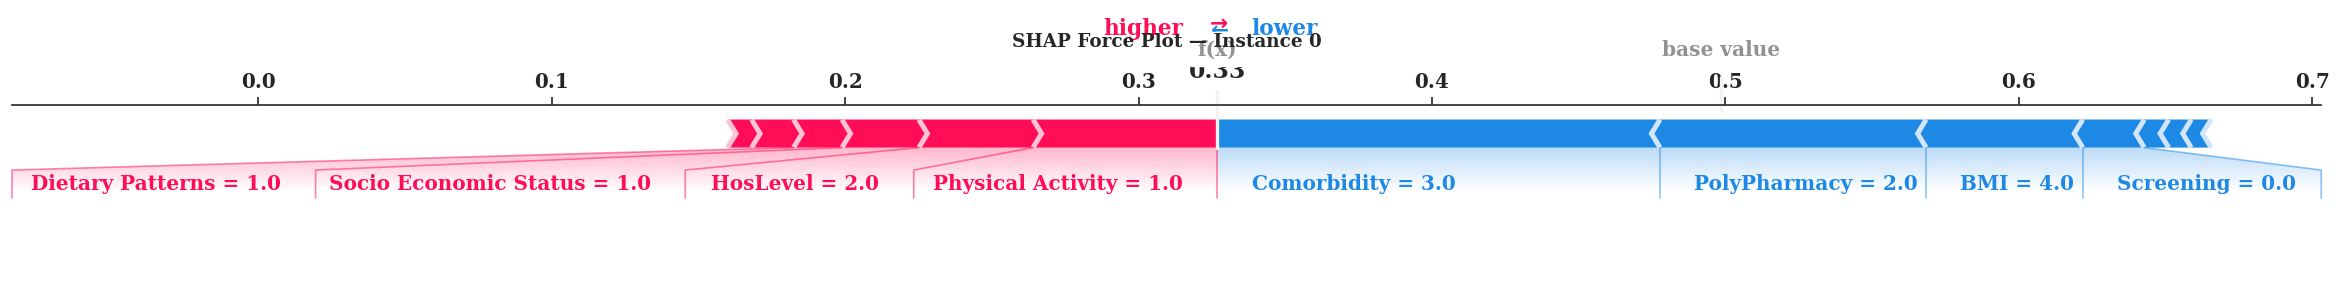

Saved: rf_shap_force.png


In [39]:
# ==============================================================
# Plot 4 — Force Plot
# ==============================================================
print(f'\n--- Plot 4: Force Plot (Instance {INSTANCE_IDX}) ---')

plt.figure(figsize=(14, 3))
shap.force_plot(
    base_val,
    sv[INSTANCE_IDX],
    X_test[INSTANCE_IDX],          # ✅ FIX HERE
    feature_names=FEATURE_NAMES,
    matplotlib=True,
    show=False
)

plt.title(
    f'SHAP Force Plot — Instance {INSTANCE_IDX}',
    fontsize=11,
    pad=15
)

plt.tight_layout()
plt.savefig('rf_shap_force.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: rf_shap_force.png')


--- Plot 5: SHAP Heatmap ---


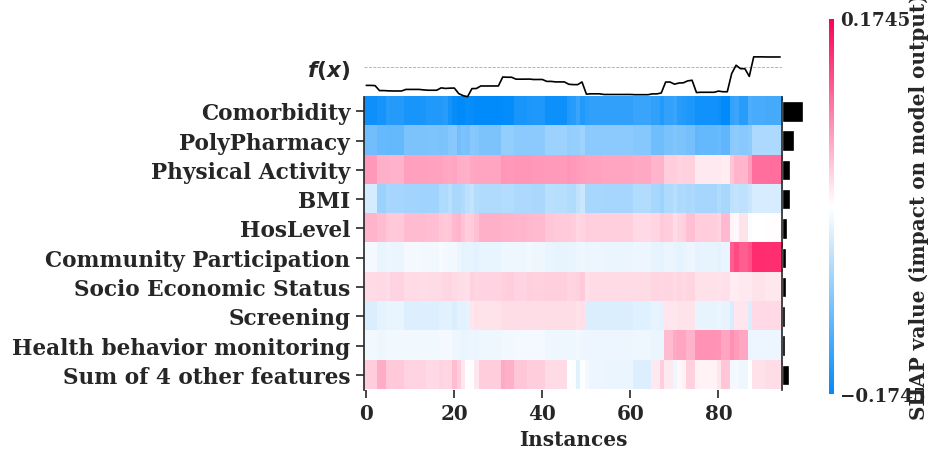

Saved: rf_shap_heatmap.png


In [40]:
# ==============================================================
# Plot 5 — Heatmap
# ==============================================================
print('\n--- Plot 5: SHAP Heatmap ---')

shap_explanation = shap.Explanation(
    values        = sv,
    base_values   = np.full(len(sv), base_val),
    data          = X_test,          # ✅ FIX HERE (no .values)
    feature_names = FEATURE_NAMES
)

plt.figure(figsize=(12, 6))
shap.plots.heatmap(shap_explanation, show=False)

plt.title('', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('rf_shap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: rf_shap_heatmap.png')

In [ ]:
# ==============================================================
# Top Features — ranked table
# ==============================================================
print()
print('=' * 60)
print('Top Features by Mean |SHAP| — Random Forest')
print('=' * 60)

mean_shap = np.abs(sv).mean(axis=0)
shap_rank = pd.DataFrame({
    'Feature'    : FEATURE_NAMES,
    'Mean |SHAP|': np.round(mean_shap, 4)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

shap_rank.index = shap_rank.index + 1
print(shap_rank.to_string(index=False))

print()
print('Saved figures:')
print('  rf_shap_beeswarm.png')
print('  rf_shap_bar.png')
print('  rf_shap_waterfall.png')
print('  rf_shap_force.png')
print('  rf_shap_heatmap.png')

## Section 14 — Save Models & Final Summary

In [28]:
import joblib

os.makedirs('saved_models', exist_ok=True)

# sklearn + boosting
for mname, clf in [
    ('MLP',           mlp_model),
    ('Random_Forest', rf_model),
    ('CatBoost',      cb_model),
    ('XGBoost',       xgb_model),
    ('LightGBM',      lgbm_model),
    ('AdaBoost',      ada_model),
]:
    joblib.dump(clf, f'saved_models/{mname}.pkl')
    print(f'Saved {mname}.pkl')

# Keras ANN
ann_model.save('saved_models/ANN.keras')
print('Saved ANN.keras')

# Scaler
joblib.dump(scaler, 'saved_models/scaler.pkl')
print('Saved scaler.pkl')

Saved MLP.pkl
Saved Random_Forest.pkl
Saved CatBoost.pkl
Saved XGBoost.pkl
Saved LightGBM.pkl
Saved AdaBoost.pkl


NameError: name 'ann_model' is not defined